# 06 — Workload Breakdown

**Benchmark focus:** workload-level analysis across Filter, GroupBy, Join, and Pipeline.  
**Main evidence:** real-data row scaling results from `1M`, `10M`, and `50M`.  
**Supporting evidence:** physical scaling, synthetic stress, 100M scale, and Colab/runtime results.

Notebook này phân tích benchmark theo góc nhìn **workload** thay vì chỉ theo framework hoặc dataset size. Notebook không chạy benchmark workload; chỉ đọc các CSV đã sinh trong `results/raw/`.


## 1. Research Questions

Notebook này trả lời các câu hỏi:

1. Workload nào tốn runtime nhất?
2. Workload nào tạo memory pressure lớn nhất?
3. Framework nào phù hợp nhất với từng workload?
4. Join có thật sự đắt hơn GroupBy không?
5. Pipeline có làm chi phí tăng mạnh so với workload đơn lẻ không?
6. Ranking framework có thay đổi theo workload không?
7. Workload nào nhạy nhất với dataset size, memory pressure, skew, hoặc environment?


## 2. Setup and Data Loading

Section này load toàn bộ result files cần thiết, nhưng tách rõ **main results** và **supporting results**. Main ranking chỉ dùng real row-scaling results; các nhóm khác chỉ dùng để bổ sung insight.


In [75]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() in {"benchmark", "benchmarks", "notebooks"}:
    PROJECT_ROOT = PROJECT_ROOT.parent
if PROJECT_ROOT.name.lower() == "benchmark":
    PROJECT_ROOT = PROJECT_ROOT.parent
if (PROJECT_ROOT / "results" / "raw").exists() is False:
    # Common case when the notebook is launched from notebooks/benchmark.
    candidate = Path.cwd().resolve().parents[1]
    if (candidate / "results" / "raw").exists():
        PROJECT_ROOT = candidate

RAW_DIR = PROJECT_ROOT / "results" / "raw"
PLOT_DIR = PROJECT_ROOT / "results" / "figures" / "06_workload_breakdown"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

WORKLOAD_ORDER = ["filter", "groupby", "join", "pipeline"]
ROW_ORDER = ["1M", "10M", "50M"]
FRAMEWORK_ORDER = ["pandas", "polars_lazy", "polars_eager", "dask"]

plt.style.use("seaborn-v0_8-whitegrid")


In [76]:
MAIN_REAL_FILES = {
    "pandas": RAW_DIR / "pandas_real_results.csv",
    "polars_lazy": RAW_DIR / "polars_real_results.csv",
    "polars_eager": RAW_DIR / "polars_eager_real_results.csv",
    "dask": RAW_DIR / "dask_real_results.csv",
}

SIZE_FILES = {
    "pandas": RAW_DIR / "pandas_size_results.csv",
    "polars_lazy": RAW_DIR / "polars_size_results.csv",
    "polars_eager": RAW_DIR / "polars_eager_size_results.csv",
    "dask": RAW_DIR / "dask_size_results.csv",
}

STRESS_FILES = {
    "pandas": RAW_DIR / "pandas_highuid_skewed_results.csv",
    "polars_lazy": RAW_DIR / "polars_highuid_skewed_results.csv",
    "polars_eager": RAW_DIR / "polars_eager_highuid_skewed_results.csv",
    "dask": RAW_DIR / "dask_highuid_skewed_results.csv",
}

SCALE_100M_FILES = {
    "polars_lazy": RAW_DIR / "polars_100m_results.csv",
    "dask": RAW_DIR / "dask_100m_results.csv",
}

COLAB_FILES = {
    "pandas": RAW_DIR / "pandas_colab_results.csv",
    "polars_lazy": RAW_DIR / "polars_colab_results.csv",
    "polars_eager": RAW_DIR / "polars_eager_colab_results.csv",
    "dask": RAW_DIR / "dask_colab_results.csv",
}


In [77]:
def load_result_group(file_map, benchmark_group_label):
    frames = []

    for framework, path in file_map.items():
        if not path.exists():
            print(f"[WARN] Missing file: {path}")
            continue

        df = pd.read_csv(path)
        df["framework_group"] = framework
        df["source_file"] = path.name
        df["analysis_group"] = benchmark_group_label
        frames.append(df)

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)
    if "time_s" in out.columns and "runtime_sec" not in out.columns:
        out["runtime_sec"] = out["time_s"]
    if "peak_memory_mb" in out.columns:
        out["peak_memory_gb"] = out["peak_memory_mb"] / 1024
    return out


def ordered_category(series, order):
    return pd.Categorical(series, categories=order, ordered=True)


def safe_display(df, n=20):
    if df.empty:
        print("No rows available.")
    else:
        display(df.head(n))


In [78]:
df_real = load_result_group(MAIN_REAL_FILES, "main_real_row_scaling")
df_size = load_result_group(SIZE_FILES, "support_physical_scaling")
df_stress = load_result_group(STRESS_FILES, "support_synthetic_stress")
df_100m = load_result_group(SCALE_100M_FILES, "support_100m_scale")
df_colab = load_result_group(COLAB_FILES, "support_colab_environment")

df_all = pd.concat(
    [df_real, df_size, df_stress, df_100m, df_colab],
    ignore_index=True,
)

df_real_ok = df_real[df_real["status"] == "ok"].copy()
df_size_ok = df_size[df_size["status"] == "ok"].copy()
df_stress_ok = df_stress[df_stress["status"] == "ok"].copy()
df_100m_ok = df_100m[df_100m["status"] == "ok"].copy()
df_colab_ok = df_colab[df_colab["status"] == "ok"].copy()

df_fail = df_all[df_all["status"] != "ok"].copy()

for frame in [df_real, df_size, df_stress, df_100m, df_colab, df_all, df_real_ok]:
    if not frame.empty:
        frame["workload"] = ordered_category(frame["workload"], WORKLOAD_ORDER)
        frame["framework_group"] = ordered_category(frame["framework_group"], FRAMEWORK_ORDER)


## 3. Result File Inventory and Benchmark Group Mapping

Bảng dưới đây giải thích file nào thuộc benchmark nào. Đây là boundary quan trọng: notebook có thể load nhiều CSV, nhưng **không trộn tất cả vào ranking chính**.


In [79]:
def inventory_rows(file_map, group_label, role):
    rows = []
    for framework, path in file_map.items():
        rows.append({
            "analysis_group": group_label,
            "framework_group": framework,
            "file": path.name,
            "exists": path.exists(),
            "role": role,
        })
    return rows

inventory = pd.DataFrame(
    inventory_rows(MAIN_REAL_FILES, "Main real row scaling", "Main analysis")
    + inventory_rows(SIZE_FILES, "Physical scaling", "Supporting memory-pressure analysis")
    + inventory_rows(STRESS_FILES, "Synthetic stress", "Supporting skew/cardinality analysis")
    + inventory_rows(SCALE_100M_FILES, "100M scale", "Supporting large-scale feasibility")
    + inventory_rows(COLAB_FILES, "Colab environment", "Supporting environment sensitivity")
)

inventory


,analysis_group,framework_group,file,exists,role
0,Main real row scaling,pandas,pandas_real_results.csv,True,Main analysis
1,Main real row scaling,polars_lazy,polars_real_results.csv,True,Main analysis
2,Main real row scaling,polars_eager,polars_eager_real_results.csv,True,Main analysis
3,Main real row scaling,dask,dask_real_results.csv,True,Main analysis
4,Physical scaling,pandas,pandas_size_results.csv,True,Supporting memory-pressure analysis
5,Physical scaling,polars_lazy,polars_size_results.csv,True,Supporting memory-pressure analysis
6,Physical scaling,polars_eager,polars_eager_size_results.csv,True,Supporting memory-pressure analysis
7,Physical scaling,dask,dask_size_results.csv,True,Supporting memory-pressure analysis
8,Synthetic stress,pandas,pandas_highuid_skewed_results.csv,True,Supporting skew/cardinality analysis
9,Synthetic stress,polars_lazy,polars_highuid_skewed_results.csv,True,Supporting skew/cardinality analysis


### Nhận xét

Bảng `Result File Inventory` cho thấy toàn bộ các file kết quả cần thiết đều đã tồn tại, với `exists = True` cho cả 18 file. Điều này nghĩa là notebook có đủ dữ liệu để tiếp tục các bước phân tích tiếp theo mà không gặp lỗi thiếu file đầu vào.

Nhóm `Main real row scaling` gồm bốn file chính:

- `pandas_real_results.csv`
- `polars_real_results.csv`
- `polars_eager_real_results.csv`
- `dask_real_results.csv`

Đây là nhóm dữ liệu quan trọng nhất của notebook và sẽ được dùng cho `main analysis`, bao gồm workload runtime ranking, memory comparison, framework ranking, và workload sensitivity theo dataset size.

Các nhóm còn lại chỉ đóng vai trò `supporting evidence`. Cụ thể, nhóm `Physical scaling` được dùng để giải thích memory-pressure behavior, nhóm `Synthetic stress` được dùng để kiểm tra skew/cardinality sensitivity, nhóm `100M scale` dùng để đánh giá large-scale feasibility, và nhóm `Colab environment` dùng để xem xét environment sensitivity.

Vì notebook đã phân tách rõ `Main analysis` và `Supporting analysis`, các kết luận ranking chính sẽ không bị trộn lẫn giữa các benchmark group có mục tiêu khác nhau. Đây là boundary quan trọng để giữ cho phần workload breakdown có tính diễn giải rõ ràng và đúng với thiết kế benchmark.

## 4. Analysis Scope

Phần `main workload breakdown` trong notebook này chỉ sử dụng **real-data benchmark results** làm nguồn phân tích chính.

Các nhóm kết quả `Physical scaling`, `Synthetic stress`, `100M scale`, và `Colab environment` chỉ được dùng làm `supporting evidence`. Chúng không được trộn vào các bảng `main ranking` vì mỗi benchmark group kiểm soát một primary variable khác nhau. Nếu trộn trực tiếp các nhóm này, kết luận về workload hoặc framework ranking có thể bị sai lệch.

**Main scope:**

- Dataset type: real data
- Frameworks: Pandas, Polars Lazy, Polars Eager, Dask
- Workloads: Filter, GroupBy, Join, Pipeline
- Dataset sizes: `1M`, `10M`, `50M`
- Status: `ok` only

**Supporting scope:**

- Physical scaling: dùng để giải thích memory pressure behavior
- Synthetic stress: dùng để kiểm tra skew/high-cardinality sensitivity
- 100M scale: dùng để đánh giá large-scale feasibility
- Colab environment: dùng để xem xét environment sensitivity

Boundary này giúp notebook giữ đúng mục tiêu: kết luận chính về workload cost và framework ranking được rút ra từ real-data results, còn các nhóm result khác chỉ giúp giải thích vì sao một workload có thể trở nên nhạy hơn trong điều kiện memory pressure, skewed keys, large scale, hoặc constrained runtime environment.

## 5. Workload Semantics

Phần này mô tả ý nghĩa của từng `workload` trước khi phân tích số liệu. Mục tiêu là làm rõ mỗi workload đang stress phần nào của dataframe system, từ đó giúp diễn giải runtime, memory usage, và framework ranking ở các section sau.

### 5.1 Filter

`Filter` là workload thiên về scan-heavy và materialization-sensitive.

Workload này thường bao gồm đọc dữ liệu, áp dụng điều kiện lọc, và materialize phần kết quả thỏa điều kiện. Nếu framework hỗ trợ tốt predicate pushdown hoặc chỉ cần đọc một số cột cần thiết, chi phí có thể thấp. Tuy nhiên, nếu nhiều dòng thỏa điều kiện và output DataFrame lớn, chi phí memory allocation và result materialization có thể tăng đáng kể.

Vì vậy, `Filter` không chỉ đo chi phí của boolean predicate, mà còn phản ánh khả năng scan parquet, decode dữ liệu, pushdown điều kiện, và materialize output.

### 5.2 GroupBy

`GroupBy` là workload thiên về aggregation-heavy.

Chi phí của workload này phụ thuộc nhiều vào key cardinality, kích thước hash table, số lượng group đầu ra, và cách framework xử lý aggregation. Nếu số lượng group nhỏ, output thường gọn và workload có thể ổn định hơn. Nếu key cardinality cao hoặc phân phối key bị skew, hash table có thể lớn hơn, memory usage tăng, và runtime có thể bị kéo dài.

Vì vậy, `GroupBy` phù hợp để đánh giá khả năng aggregation, hash-based execution, và memory efficiency của từng framework.

### 5.3 Join

`Join` là workload thiên về key-matching, hash table construction, và memory pressure.

Chi phí của workload này phụ thuộc vào join key cardinality, kích thước hai bảng đầu vào, chiến lược join của framework, shuffle hoặc partition handling, và kích thước output sau join. Trong nhiều trường hợp, `Join` có thể tạo memory pressure cao hơn `Filter` hoặc `GroupBy` vì framework cần xây dựng cấu trúc trung gian để match key và có thể phải materialize output lớn.

Vì vậy, `Join` thường là workload quan trọng để phát hiện bottleneck về memory, hash table size, partition imbalance, và framework stability.

### 5.4 Pipeline

`Pipeline` là workload kết hợp nhiều operation trong cùng một query hoặc workflow.

Chi phí của `Pipeline` phụ thuộc vào thứ tự operation, kích thước intermediate results, và khả năng optimizer của framework. Nếu framework có thể tối ưu toàn bộ query plan, ví dụ projection pushdown, predicate pushdown, hoặc tránh materialize intermediate DataFrame, runtime có thể thấp hơn tổng chi phí của từng bước riêng lẻ. Ngược lại, nếu intermediate results lớn hoặc phải materialize nhiều lần, `Pipeline` có thể trở thành workload rất tốn runtime và memory.

Vì vậy, `Pipeline` giúp đánh giá khả năng xử lý end-to-end workflow thực tế, không chỉ hiệu năng của từng operator riêng lẻ.

## 6. Data Completeness and Validity Check

Section này kiểm tra dữ liệu có đủ để phân tích không: đủ framework, workload, dataset size, số run thành công, và failed runs nếu có.


In [80]:
result_count = (
    df_real
    .groupby(["framework_group", "workload", "dataset_size", "status"], observed=True)
    .size()
    .rename("n_rows")
    .reset_index()
    .sort_values(["framework_group", "workload", "dataset_size", "status"])
)

result_count


,framework_group,workload,dataset_size,status,n_rows
0,pandas,filter,10M,ok,3
1,pandas,filter,1M,ok,3
2,pandas,filter,50M,ok,3
3,pandas,groupby,10M,ok,3
4,pandas,groupby,1M,ok,3
5,pandas,groupby,50M,ok,3
6,pandas,join,10M,ok,3
7,pandas,join,1M,ok,3
8,pandas,join,50M,ok,3
9,pandas,pipeline,10M,ok,3


### Nhận xét

Bảng `Data Completeness and Validity Check` cho thấy dữ liệu main analysis đã đầy đủ cho toàn bộ tổ hợp cần phân tích. Cụ thể, cả bốn `framework_group` gồm `pandas`, `polars_lazy`, `polars_eager`, và `dask` đều có đủ bốn `workload`: `filter`, `groupby`, `join`, và `pipeline`.

Mỗi workload được chạy trên đủ ba `dataset_size`: `1M`, `10M`, và `50M`. Với mỗi tổ hợp `framework_group × workload × dataset_size`, số run thành công là `3`, và toàn bộ các dòng đều có `status = ok`.

Điều này xác nhận rằng main real-data results đủ điều kiện để phân tích workload-level một cách cân bằng. Các so sánh về runtime, memory usage, framework ranking, và workload sensitivity ở các section sau có thể được thực hiện trên cùng một tập tổ hợp đầy đủ, không bị lệch do thiếu framework, thiếu workload, thiếu dataset size, hoặc failed runs trong main analysis.

Tóm lại, dữ liệu main analysis đạt yêu cầu completeness và validity để tiếp tục phân tích.

In [81]:
expected = pd.MultiIndex.from_product(
    [FRAMEWORK_ORDER, WORKLOAD_ORDER, ROW_ORDER],
    names=["framework_group", "workload", "dataset_size"],
).to_frame(index=False)

observed_ok = (
    df_real_ok[["framework_group", "workload", "dataset_size"]]
    .drop_duplicates()
    .astype(str)
)

missing_combinations = (
    expected.merge(observed_ok, on=["framework_group", "workload", "dataset_size"], how="left", indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
)

if missing_combinations.empty:
    print("No missing successful main-result combinations.")
else:
    display(missing_combinations)


No missing successful main-result combinations.


In [82]:
failure_summary = (
    df_fail
    .groupby(["analysis_group", "framework_group", "workload", "dataset_size", "status"], observed=True)
    .size()
    .rename("n_failed_rows")
    .reset_index()
    .sort_values(["analysis_group", "framework_group", "workload", "dataset_size"])
)

if failure_summary.empty:
    print("No failed runs found across loaded result groups.")
else:
    display(failure_summary)


No failed runs found across loaded result groups.


## 7. Main Workload Summary from Real Results

Bảng summary chính group theo `workload` và `framework_group`, dùng only successful runs từ real row-scaling benchmark.


In [83]:
summary = (
    df_real_ok
    .groupby(["workload", "framework_group"], observed=True)
    .agg(
        mean_runtime=("runtime_sec", "mean"),
        std_runtime=("runtime_sec", "std"),
        mean_memory=("peak_memory_mb", "mean"),
        std_memory=("peak_memory_mb", "std"),
        mean_throughput=("throughput_rows_per_s", "mean"),
        n_runs=("runtime_sec", "count"),
    )
    .reset_index()
    .sort_values(["workload", "mean_runtime"])
)

summary


,workload,framework_group,mean_runtime,std_runtime,mean_memory,std_memory,mean_throughput,n_runs
1,filter,polars_lazy,11.532633,14.380328,5510.014444,5331.483503,2.362681e+06,9
3,filter,dask,13.564144,15.454658,5999.287778,4163.209359,1.516446e+06,9
2,filter,polars_eager,18.437278,26.097509,4373.487778,3108.538828,3.226588e+06,9
0,filter,pandas,252.639478,354.019721,6500.055556,4422.024539,2.922776e+05,9
7,groupby,dask,5.550411,4.747720,3117.016667,1829.398941,3.191085e+06,9
5,groupby,polars_lazy,7.886122,8.313875,6179.200000,4763.094728,2.204102e+06,9
6,groupby,polars_eager,27.672833,39.004661,5060.890000,3552.202988,2.111503e+06,9
4,groupby,pandas,156.916033,213.767768,6385.127778,4338.969350,2.889421e+05,9
10,join,polars_eager,19.370056,25.648560,4954.616667,2254.459004,1.570685e+06,9
9,join,polars_lazy,36.571611,43.281448,6572.795556,4300.383329,5.676678e+05,9


### Nhận xét

Bảng `Main Workload Summary from Real Results` cho thấy workload cost thay đổi rất rõ theo cả `workload` và `framework_group`. Mỗi tổ hợp workload-framework có `n_runs = 9`, tương ứng với 3 dataset size và 3 repeated runs, nên bảng này đủ ổn định để dùng làm overview cho các phân tích runtime, memory, throughput và ranking ở các section sau.

Về runtime, `pandas` chậm hơn đáng kể so với các framework còn lại ở tất cả workload. Khoảng cách đặc biệt lớn ở `filter`, `join`, và `pipeline`, cho thấy Pandas không phù hợp khi workload real-data tăng lên các scale lớn hơn. Ngược lại, nhóm `polars_lazy`, `polars_eager`, và `dask` có runtime thấp hơn nhiều, nhưng ranking thay đổi theo workload.

Ở workload `filter`, `polars_lazy` có mean runtime thấp nhất, theo sau là `dask` và `polars_eager`. Tuy nhiên, `polars_eager` lại có mean throughput cao nhất trong bảng filter, cho thấy throughput và mean runtime có thể không luôn dẫn đến cùng một ranking khi dữ liệu được aggregate qua nhiều dataset size.

Ở workload `groupby`, `dask` có mean runtime thấp nhất và mean memory thấp hơn nhiều so với Polars và Pandas. Điều này cho thấy Dask hoạt động tốt trong aggregation workload trên nhóm real results này.

Ở workload `join`, `polars_eager` là framework nhanh nhất, trong khi `dask` và đặc biệt là `pandas` tốn runtime cao hơn nhiều. Đây là tín hiệu cho thấy join workload là một trong các workload phân biệt framework rõ nhất, vì nó nhạy với join strategy, hash table construction, memory pressure và output materialization.

Ở workload `pipeline`, `polars_lazy` có mean runtime thấp nhất, cho thấy lazy execution có lợi khi workload gồm nhiều bước và framework có thể tối ưu toàn bộ query plan. Pandas tiếp tục là framework chậm nhất trong pipeline workload.

Về memory usage, `join` và `pipeline` nhìn chung là các workload tạo memory pressure lớn hơn. `dask` có mean memory cao nhất trong `join`, trong khi `polars_lazy` có mean memory cao nhất trong `pipeline`. Điều này cho thấy workload memory cost không chỉ phụ thuộc vào workload type mà còn phụ thuộc vào execution strategy của từng framework.

Một điểm cần lưu ý là `std_runtime` và `std_memory` khá lớn ở nhiều tổ hợp, đặc biệt với `pandas`, `polars_eager`, và các workload trên dataset lớn. Điều này hợp lý vì bảng đang aggregate chung cả `1M`, `10M`, và `50M`, nên độ lệch chuẩn phản ánh cả biến thiên theo dataset size chứ không chỉ noise giữa repeated runs.

Tóm lại, bảng này xác nhận rằng không nên đưa ra một ranking framework duy nhất cho toàn bộ benchmark. Ranking thay đổi theo workload: `polars_lazy` nổi bật ở `filter` và `pipeline`, `dask` nổi bật ở `groupby`, còn `polars_eager` nổi bật ở `join`. Các section tiếp theo nên tiếp tục tách theo workload để phân tích runtime cost, memory cost, amplification so với filter, và sensitivity theo dataset size.

## 8. Runtime Cost by Workload

Mục tiêu: xác định workload nào đắt nhất về runtime trên real-data benchmark.


In [84]:
runtime_by_workload = (
    df_real_ok
    .groupby("workload", observed=True)
    .agg(
        mean_runtime=("runtime_sec", "mean"),
        median_runtime=("runtime_sec", "median"),
        std_runtime=("runtime_sec", "std"),
        n_runs=("runtime_sec", "count"),
    )
    .sort_values("mean_runtime", ascending=False)
)

runtime_by_workload


,mean_runtime,median_runtime,std_runtime,n_runs
workload,,,,
join,172.515711,24.46215,426.417372,36
pipeline,89.618292,20.95675,229.037494,36
filter,74.043383,4.90635,199.616696,36
groupby,49.506350,4.59685,121.840489,36


### Nhận xét

Bảng `Runtime Cost by Workload` cho thấy `join` là workload có mean runtime cao nhất, đạt khoảng `172.52s`, tiếp theo là `pipeline` với khoảng `89.62s`, `filter` với khoảng `74.04s`, và thấp nhất là `groupby` với khoảng `49.51s`.

Thứ tự theo mean runtime là:

```text
join > pipeline > filter > groupby
```

Điều này cho thấy `join` là workload tốn thời gian nhất trong real-data benchmark. Kết quả này hợp lý vì join thường phải thực hiện key matching, xây dựng hash table hoặc cấu trúc trung gian, xử lý memory allocation, và materialize output. Đây là workload nhạy hơn với key cardinality, join strategy, và memory pressure so với các workload đơn giản hơn.

Tuy nhiên, cần chú ý rằng median runtime thấp hơn mean runtime rất nhiều ở tất cả workload. Ví dụ, `join` có mean runtime khoảng `172.52s` nhưng median chỉ khoảng `24.46s`; `filter` có mean khoảng `74.04s` nhưng median chỉ khoảng `4.91s`. Điều này cho thấy phân phối runtime bị lệch mạnh bởi các run rất chậm, nhiều khả năng đến từ dataset size lớn hơn như `50M` hoặc từ framework chậm hơn như `pandas`.

Vì vậy, bảng này nên được hiểu theo hai tầng:

- `mean_runtime` phản ánh tổng cost trung bình khi gộp tất cả framework và dataset size.
- `median_runtime` phản ánh workload cost điển hình hơn, ít bị kéo lệch bởi các run cực chậm.

Dù vậy, cả mean và median đều cho thấy `join` là workload nặng nhất. `GroupBy` có runtime thấp nhất trong bảng này, cho thấy aggregation workload trong real-data results ổn định hơn so với `join`, `pipeline`, và `filter` khi xét tổng thể.

Tóm lại, kết quả runtime xác nhận rằng workload type ảnh hưởng rất mạnh đến benchmark behavior. Do đó, các kết luận về framework performance không nên chỉ dựa trên overall average, mà cần tiếp tục được phân tích riêng theo từng workload và từng framework.

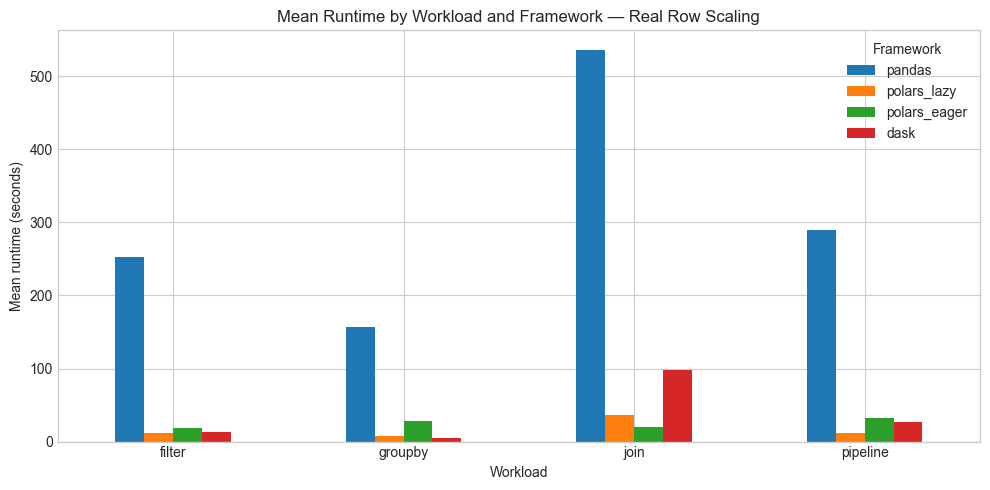

In [85]:
runtime_pivot = summary.pivot(index="workload", columns="framework_group", values="mean_runtime")
runtime_pivot = runtime_pivot.reindex(WORKLOAD_ORDER)
runtime_pivot.plot(kind="bar", figsize=(10, 5))
plt.title("Mean Runtime by Workload and Framework — Real Row Scaling")
plt.ylabel("Mean runtime (seconds)")
plt.xlabel("Workload")
plt.xticks(rotation=0)
plt.legend(title="Framework")
plt.tight_layout()
plt.savefig(PLOT_DIR / "mean_runtime_by_workload_framework.png", dpi=150, bbox_inches="tight")
plt.show()


### Nhận xét

Biểu đồ `Mean Runtime by Workload and Framework` cho thấy sự khác biệt runtime giữa các framework rất rõ ràng khi phân tích theo từng workload.

Điểm nổi bật nhất là `pandas` có mean runtime cao hơn đáng kể so với các framework còn lại ở cả bốn workload. Mức chênh lệch lớn nhất xuất hiện ở `join`, nơi `pandas` mất hơn `500s` trung bình, cao hơn nhiều so với `polars_lazy`, `polars_eager`, và `dask`. Điều này cho thấy Pandas gặp bất lợi lớn khi workload yêu cầu xử lý dữ liệu lớn theo kiểu end-to-end, đặc biệt với các operation có chi phí cao như join và pipeline.

Ở nhóm framework ngoài Pandas, ranking thay đổi theo workload. `polars_lazy` là framework nhanh nhất ở `filter` và `pipeline`, cho thấy lazy execution có lợi khi framework có thể tối ưu scan, predicate pushdown, projection pushdown, hoặc toàn bộ query plan. `dask` có runtime thấp nhất ở `groupby`, cho thấy partitioned execution có thể hiệu quả với aggregation workload trong bộ kết quả này. Với `join`, `polars_eager` có runtime thấp nhất, trong khi `dask` chậm hơn đáng kể, có thể do overhead từ partitioning, scheduling, hoặc shuffle-like behavior.

Biểu đồ cũng cho thấy `join` là workload phân biệt framework mạnh nhất. Trong khi `polars_eager` và `polars_lazy` xử lý join nhanh hơn nhiều so với Pandas, `dask` vẫn có runtime cao hơn đáng kể so với Polars. Điều này cho thấy join không chỉ phụ thuộc vào kích thước dữ liệu mà còn phụ thuộc mạnh vào execution strategy của từng framework.

Đối với `pipeline`, `polars_lazy` có lợi thế rõ ràng hơn so với `polars_eager` và `dask`. Đây là tín hiệu phù hợp với kỳ vọng rằng lazy execution có thể tối ưu nhiều bước trong cùng một workflow và tránh một phần intermediate materialization.

Tóm lại, biểu đồ này củng cố kết luận rằng không nên đưa ra một ranking framework duy nhất cho mọi workload. `pandas` là framework chậm nhất trong tất cả workload ở scale này, nhưng giữa `polars_lazy`, `polars_eager`, và `dask`, framework tốt nhất phụ thuộc vào workload: `polars_lazy` mạnh ở filter và pipeline, `dask` mạnh ở groupby, còn `polars_eager` mạnh ở join.

In [86]:
most_runtime_expensive = runtime_by_workload.index[0]
print(f"Most runtime-expensive workload on average: {most_runtime_expensive}")

Most runtime-expensive workload on average: join


### Key Finding

Kết quả tính toán xác nhận rằng `join` là workload có `mean_runtime` cao nhất trong main real-data benchmark.

Điều này phù hợp với bảng runtime summary và biểu đồ mean runtime theo workload-framework ở trên. `Join` thường là workload nặng vì nó không chỉ đọc dữ liệu và thực hiện operation đơn giản, mà còn phải match key giữa các bảng, xây dựng hash table hoặc cấu trúc trung gian, xử lý memory allocation, và materialize kết quả sau join.

Do đó, trong notebook này, `join` nên được xem là workload runtime-expensive nhất. Các phân tích tiếp theo về memory usage, framework ranking, và workload sensitivity nên đặc biệt chú ý đến `join`, vì đây là workload dễ bộc lộ khác biệt execution strategy giữa Pandas, Polars, và Dask.

## 9. Relative Runtime vs Filter Baseline

Runtime amplification được tính trong từng cặp `framework_group + dataset_size`:

```text
runtime_amplification = workload_runtime / filter_runtime
```

Sau đó aggregate theo workload và framework. Cách này tránh so trực tiếp workload ở các size/framework khác nhau.


In [87]:
combo_runtime = (
    df_real_ok
    .groupby(["framework_group", "dataset_size", "workload"], observed=True)
    .agg(mean_runtime=("runtime_sec", "mean"))
    .reset_index()
)

filter_runtime = (
    combo_runtime[combo_runtime["workload"].astype(str) == "filter"]
    .rename(columns={"mean_runtime": "filter_runtime"})
    [["framework_group", "dataset_size", "filter_runtime"]]
)

runtime_amp_detail = combo_runtime.merge(filter_runtime, on=["framework_group", "dataset_size"], how="left")
runtime_amp_detail["runtime_amplification_vs_filter"] = (
    runtime_amp_detail["mean_runtime"] / runtime_amp_detail["filter_runtime"]
)

runtime_amplification = (
    runtime_amp_detail
    .groupby(["workload", "framework_group"], observed=True)
    .agg(
        mean_amplification=("runtime_amplification_vs_filter", "mean"),
        median_amplification=("runtime_amplification_vs_filter", "median"),
        n_comparisons=("runtime_amplification_vs_filter", "count"),
    )
    .reset_index()
    .sort_values(["workload", "mean_amplification"])
)

runtime_amplification


,workload,framework_group,mean_amplification,median_amplification,n_comparisons
0,filter,pandas,1.000000,1.000000,3
1,filter,polars_lazy,1.000000,1.000000,3
2,filter,polars_eager,1.000000,1.000000,3
3,filter,dask,1.000000,1.000000,3
7,groupby,dask,0.538087,0.459755,3
4,groupby,pandas,0.919159,0.865494,3
5,groupby,polars_lazy,1.156927,1.175889,3
6,groupby,polars_eager,1.502304,1.497024,3
10,join,polars_eager,1.996092,2.123924,3
8,join,pandas,3.448292,2.143515,3


### Nhận xét

Bảng `Relative Runtime vs Filter Baseline` cho thấy mức độ runtime amplification của từng workload so với `filter` trong cùng `framework_group` và cùng `dataset_size`. Vì `filter` được dùng làm baseline, tất cả dòng `filter` đều có `mean_amplification = 1.0`.

Cách tính này hợp lý vì nó tránh so sánh trực tiếp runtime giữa các framework hoặc dataset size khác nhau. Thay vào đó, mỗi workload được so với `filter` trong cùng điều kiện chạy, sau đó mới aggregate theo workload và framework.

Kết quả cho thấy `join` và `pipeline` là hai workload có amplification cao nhất ở hầu hết framework. Điều này xác nhận rằng hai workload này tạo thêm chi phí đáng kể so với scan/filter baseline.

Với `join`, mức amplification khác nhau rất mạnh giữa các framework. `polars_eager` có mean amplification khoảng `2.00x`, thấp nhất trong nhóm join, cho thấy join chỉ tốn khoảng gấp đôi filter trong cùng điều kiện. `pandas` có mean amplification khoảng `3.45x`. Trong khi đó, `polars_lazy` tăng lên khoảng `6.73x`, và `dask` cao nhất với khoảng `9.48x`. Điều này cho thấy join đặc biệt làm tăng runtime cost đối với Dask và Polars Lazy trong bộ kết quả này, dù absolute runtime của Polars Lazy vẫn có thể thấp hơn Pandas.

Với `pipeline`, amplification cũng cao. `pandas` có mean amplification khoảng `1.75x`, `polars_eager` khoảng `2.57x`, `polars_lazy` khoảng `5.04x`, và `dask` khoảng `11.58x`. Điều này cho thấy pipeline có thể làm tăng chi phí đáng kể so với filter, đặc biệt với Dask. Tuy nhiên, cần diễn giải cùng với absolute runtime, vì amplification cao không nhất thiết đồng nghĩa framework chậm nhất nếu filter baseline của framework đó vốn rất nhanh.

Với `groupby`, kết quả thú vị hơn: `dask` và `pandas` có amplification nhỏ hơn `1.0`, nghĩa là groupby trung bình nhanh hơn filter trong cùng framework-size pair. Điều này có thể xảy ra nếu groupby tạo output nhỏ hơn nhiều so với filter, trong khi filter phải materialize nhiều dòng kết quả. Ngược lại, `polars_lazy` và `polars_eager` có amplification lớn hơn `1.0`, cho thấy groupby đắt hơn filter đối với hai chế độ Polars trong bộ kết quả này.

Một điểm cần chú ý là `mean_amplification` và `median_amplification` có thể khác nhau khá lớn, đặc biệt ở `polars_lazy` và `dask`. Ví dụ, `dask pipeline` có mean amplification khoảng `11.58x` nhưng median chỉ khoảng `3.92x`. Điều này cho thấy một số dataset size hoặc run cụ thể tạo amplification rất cao và kéo mean lên. Vì vậy, khi diễn giải workload amplification, nên xem cả mean và median thay vì chỉ dựa vào mean.

Tóm lại, bảng này cho thấy `join` và `pipeline` là hai workload làm tăng runtime mạnh nhất so với `filter baseline`. Tuy nhiên, amplification cần được đọc cùng với absolute runtime và dataset-size sensitivity để tránh kết luận sai về framework ranking.

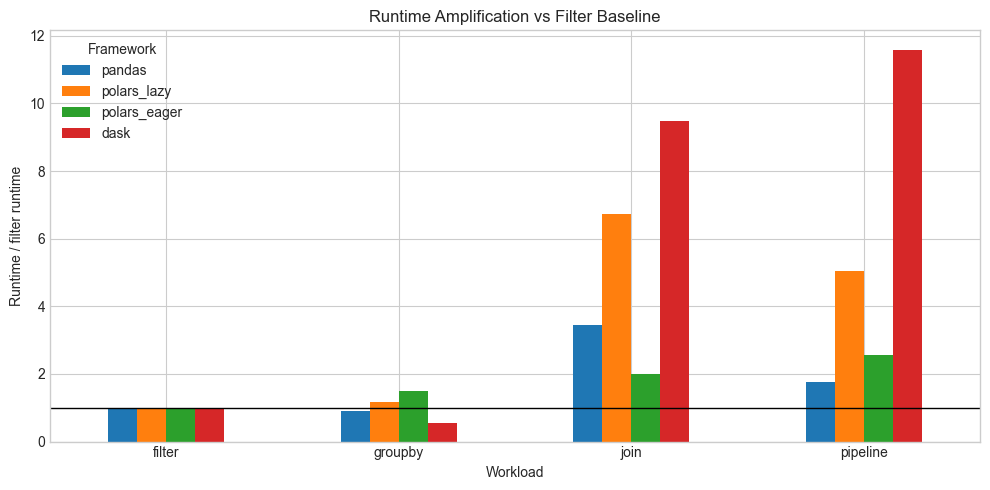

In [88]:
amp_pivot = runtime_amplification.pivot(index="workload", columns="framework_group", values="mean_amplification")
amp_pivot = amp_pivot.reindex(WORKLOAD_ORDER)
amp_pivot.plot(kind="bar", figsize=(10, 5))
plt.axhline(1.0, color="black", linewidth=1)
plt.title("Runtime Amplification vs Filter Baseline")
plt.ylabel("Runtime / filter runtime")
plt.xlabel("Workload")
plt.xticks(rotation=0)
plt.legend(title="Framework")
plt.tight_layout()
plt.savefig(PLOT_DIR / "runtime_amplification_vs_filter_baseline.png", dpi=150, bbox_inches="tight")
plt.show()


### Nhận xét

Biểu đồ `Runtime Amplification vs Filter Baseline` cho thấy mức tăng runtime của từng workload so với `filter baseline`. Đường ngang tại `1.0` biểu thị mức runtime bằng với `filter`; các cột cao hơn `1.0` nghĩa là workload đó chậm hơn filter trong cùng `framework_group` và `dataset_size`.

Kết quả cho thấy `join` và `pipeline` là hai workload có runtime amplification cao nhất. Điều này xác nhận rằng hai workload này tạo thêm chi phí đáng kể so với scan/filter baseline, đặc biệt ở các framework có scheduling, partitioning hoặc intermediate materialization overhead lớn.

Với `join`, `dask` có amplification cao nhất, gần `9.5x`, tiếp theo là `polars_lazy` khoảng `6.7x`, `pandas` khoảng `3.4x`, và `polars_eager` khoảng `2.0x`. Điều này cho thấy join làm tăng runtime mạnh nhất đối với Dask và Polars Lazy trong phép đo tương đối, dù absolute runtime vẫn cần được xem riêng để đánh giá framework nhanh/chậm tổng thể.

Với `pipeline`, pattern tương tự xuất hiện rõ hơn: `dask` có amplification cao nhất, khoảng `11.6x`, tiếp theo là `polars_lazy` khoảng `5.0x`, `polars_eager` khoảng `2.6x`, và `pandas` khoảng `1.8x`. Điều này cho thấy pipeline có thể tạo chi phí cao hơn filter rất nhiều, nhất là khi workflow gồm nhiều bước và có intermediate results lớn.

Ở `groupby`, amplification thấp hơn nhiều. `dask` và `pandas` nằm dưới baseline `1.0`, nghĩa là groupby nhanh hơn filter trong cùng điều kiện. Điều này có thể xảy ra vì groupby thường materialize output nhỏ hơn, trong khi filter có thể phải trả về nhiều dòng kết quả. Ngược lại, `polars_lazy` và `polars_eager` nằm trên baseline, cho thấy groupby đắt hơn filter đối với hai chế độ Polars trong bộ kết quả này.

Tóm lại, biểu đồ này nhấn mạnh rằng `join` và `pipeline` là hai workload làm tăng runtime mạnh nhất so với filter baseline. Tuy nhiên, amplification là thước đo tương đối; cần đọc cùng với absolute runtime để tránh kết luận sai về framework ranking.

In [89]:
join_groupby_amp = (
    runtime_amp_detail
    .pivot_table(
        index=["framework_group", "dataset_size"],
        columns="workload",
        values="runtime_amplification_vs_filter",
        observed=True,
    )
    .reset_index()
)

if {"join", "groupby"}.issubset(join_groupby_amp.columns):
    join_groupby_amp["join_vs_groupby_runtime"] = join_groupby_amp["join"] / join_groupby_amp["groupby"]
    display(join_groupby_amp[["framework_group", "dataset_size", "join_vs_groupby_runtime"]])
    print("Mean join/groupby runtime ratio:", round(join_groupby_amp["join_vs_groupby_runtime"].mean(), 2))
else:
    print("Join/groupby comparison is unavailable because one workload is missing.")


workload,framework_group,dataset_size,join_vs_groupby_runtime
0,pandas,10M,1.498855
1,pandas,1M,5.379610
2,pandas,50M,3.522056
3,polars_lazy,10M,2.408063
4,polars_lazy,1M,8.494202
5,polars_lazy,50M,5.016847
6,polars_eager,10M,1.295430
7,polars_eager,1M,2.087604
8,polars_eager,50M,0.670420
9,dask,10M,12.494190


Mean join/groupby runtime ratio: 7.32


### Nhận xét

Bảng `join_vs_groupby_runtime` so sánh trực tiếp runtime của `join` với `groupby` trong cùng `framework_group` và cùng `dataset_size`. Giá trị lớn hơn `1.0` nghĩa là `join` chậm hơn `groupby`; giá trị nhỏ hơn `1.0` nghĩa là `join` nhanh hơn `groupby`.

Kết quả cho thấy `join` thường đắt hơn `groupby` một cách rõ rệt. Mean `join/groupby runtime ratio` đạt khoảng `7.32x`, nghĩa là xét trung bình trên các framework và dataset size, `join` mất nhiều thời gian hơn `groupby` khoảng hơn 7 lần.

Mức chênh lệch lớn nhất xuất hiện ở `dask`, với ratio khoảng `25.17x` ở `1M`, `12.49x` ở `10M`, và `19.84x` ở `50M`. Điều này cho thấy `join` tạo overhead rất lớn so với `groupby` trong Dask, có thể do chi phí key matching, partition handling, scheduling, hoặc shuffle-like behavior.

Ở `polars_lazy`, `join` cũng chậm hơn `groupby` ở cả ba dataset size, với ratio từ khoảng `2.41x` đến `8.49x`. Điều này cho thấy join vẫn là workload nặng hơn aggregation ngay cả khi dùng lazy execution.

Ở `pandas`, `join` cũng luôn chậm hơn `groupby`, với ratio từ khoảng `1.50x` đến `5.38x`. Điều này phù hợp với kỳ vọng rằng join thường cần nhiều xử lý trung gian và memory allocation hơn groupby.

Riêng `polars_eager` có một ngoại lệ ở `50M`, khi ratio chỉ khoảng `0.67x`, nghĩa là join nhanh hơn groupby trong điều kiện đó. Tuy nhiên, ở `1M` và `10M`, join vẫn chậm hơn groupby. Vì vậy, ngoại lệ này nên được diễn giải cẩn thận và có thể cần kiểm tra thêm workload implementation, output size, hoặc đặc điểm dữ liệu ở 50M.

Tóm lại, bảng này củng cố kết luận rằng `join` là workload runtime-expensive hơn `groupby` trong phần lớn trường hợp. Tuy nhiên, mức độ đắt hơn phụ thuộc mạnh vào framework và dataset size, đặc biệt rõ ở Dask.

## 10. Memory Cost by Workload

Mục tiêu: xác định workload nào tạo peak memory pressure lớn nhất. Nếu CSV có output rows hoặc output size thì notebook sẽ hiển thị thêm; với schema hiện tại, memory interpretation dựa trên `peak_memory_mb`.


In [90]:
memory_by_workload = (
    df_real_ok
    .groupby("workload", observed=True)
    .agg(
        mean_memory=("peak_memory_mb", "mean"),
        median_memory=("peak_memory_mb", "median"),
        std_memory=("peak_memory_mb", "std"),
        n_runs=("peak_memory_mb", "count"),
    )
    .sort_values("mean_memory", ascending=False)
)

memory_by_workload


,mean_memory,median_memory,std_memory,n_runs
workload,,,,
join,6856.876389,5958.075,3574.196097,36
pipeline,6073.658333,5695.905,3622.325305,36
filter,5595.711389,5397.790,4216.063589,36
groupby,5185.558611,4782.165,3855.663221,36


### Nhận xét

Bảng `Memory Cost by Workload` cho thấy `join` là workload tạo peak memory pressure cao nhất trong main real-data benchmark. Mean memory của `join` đạt khoảng `6856.88 MB`, cao hơn `pipeline` khoảng `6073.66 MB`, `filter` khoảng `5595.71 MB`, và `groupby` khoảng `5185.56 MB`.

Thứ tự theo mean memory là:

```text
join > pipeline > filter > groupby
```

Kết quả này phù hợp với kỳ vọng về workload semantics. `Join` thường cần xây dựng hash table hoặc cấu trúc trung gian để match key giữa các bảng, đồng thời có thể phải materialize output lớn. Vì vậy, nó thường gây memory pressure cao hơn các workload chỉ scan, filter, hoặc aggregate.

`Pipeline` đứng thứ hai về mean memory, cho thấy workload nhiều bước có thể tạo thêm memory pressure do intermediate results hoặc do framework phải giữ nhiều trạng thái trong quá trình thực thi. Nếu framework tối ưu tốt query plan, chi phí này có thể giảm; nếu không, intermediate materialization có thể làm memory tăng đáng kể.

`Filter` có mean memory thấp hơn `join` và `pipeline`, nhưng vẫn không phải workload nhẹ hoàn toàn. Điều này có thể xảy ra khi filter trả về nhiều dòng kết quả và cần materialize một DataFrame lớn. Vì vậy, filter workload vẫn có thể `memory-sensitive` nếu output size lớn.

GroupBy có mean memory thấp nhất trong bảng. Điều này có thể do output sau aggregation thường nhỏ hơn input, đặc biệt khi số lượng group không quá lớn. Tuy nhiên, nếu key cardinality tăng cao hoặc dữ liệu bị skew, memory usage của groupby vẫn có thể tăng mạnh trong các stress benchmark.

Một điểm cần chú ý là `std_memory` khá lớn ở tất cả workload. Điều này cho thấy peak memory thay đổi đáng kể theo dataset size và framework. Vì bảng này aggregate chung nhiều framework và nhiều dataset size, nên độ lệch chuẩn phản ánh cả khác biệt scale lẫn khác biệt execution strategy.

Tóm lại, xét theo `peak_memory_mb`, `join` là workload `memory-expensive` nhất, tiếp theo là `pipeline`. Kết quả này củng cố nhận định rằng các workload có key matching hoặc nhiều bước xử lý thường tạo memory pressure cao hơn workload aggregation đơn giản.

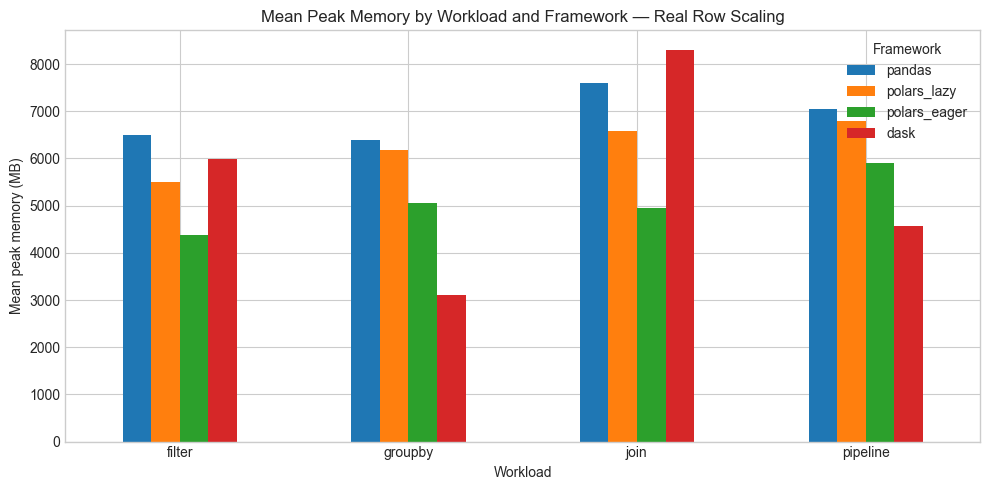

In [91]:
memory_pivot = summary.pivot(index="workload", columns="framework_group", values="mean_memory")
memory_pivot = memory_pivot.reindex(WORKLOAD_ORDER)
memory_pivot.plot(kind="bar", figsize=(10, 5))
plt.title("Mean Peak Memory by Workload and Framework — Real Row Scaling")
plt.ylabel("Mean peak memory (MB)")
plt.xlabel("Workload")
plt.xticks(rotation=0)
plt.legend(title="Framework")
plt.tight_layout()
plt.savefig(PLOT_DIR / "mean_peak_memory_by_workload_framework.png", dpi=150, bbox_inches="tight")
plt.show()


### Nhận xét

Biểu đồ `Mean Peak Memory by Workload and Framework` cho thấy peak memory không chỉ phụ thuộc vào `workload`, mà còn thay đổi rõ theo `framework_group`.

Nhìn tổng thể, `join` là workload tạo memory pressure cao nhất. Đặc biệt, `dask` có mean peak memory cao nhất ở `join`, hơn `8000 MB`, cho thấy join workload có thể gây áp lực lớn cho Dask do partition handling, intermediate states, hoặc chi phí key matching. `pandas` cũng dùng nhiều memory ở `join`, trong khi `polars_eager` thấp hơn đáng kể so với các framework còn lại.

Ở `pipeline`, `pandas` và `polars_lazy` có mean peak memory cao hơn `polars_eager` và `dask`. Điều này cho thấy pipeline workload có thể tạo memory pressure khác nhau tùy execution strategy. Với lazy execution, framework có thể tối ưu query plan, nhưng vẫn có thể giữ nhiều intermediate state hoặc materialize kết quả cuối, làm peak memory tăng.

Ở `filter`, `pandas` và `dask` có memory usage cao hơn `polars_lazy` và `polars_eager`. Điều này cho thấy filter không nhất thiết là workload nhẹ về memory, đặc biệt nếu output sau filter lớn và cần materialize DataFrame đầy đủ.

Ở `groupby`, `dask` có mean peak memory thấp nhất, trong khi `pandas` và `polars_lazy` cao hơn. Điều này phù hợp với kết quả runtime trước đó, nơi Dask cũng hoạt động tốt ở groupby. Có thể groupby trong Dask được hưởng lợi từ partitioned execution và output aggregation nhỏ hơn.

Một điểm quan trọng là không có framework nào luôn dùng ít memory nhất cho mọi workload. `polars_eager` dùng ít memory nhất ở `filter` và `join`, `dask` dùng ít memory nhất ở `groupby` và `pipeline`, trong khi `pandas` thường nằm trong nhóm memory usage cao. Điều này cho thấy memory efficiency phụ thuộc mạnh vào workload-specific execution behavior.

Tóm lại, biểu đồ này củng cố kết luận rằng `join` và `pipeline` là hai workload cần chú ý nhất về memory pressure. Tuy nhiên, ranking memory theo framework không giống ranking runtime, nên notebook cần phân tích runtime và memory như hai chiều riêng biệt thay vì gộp thành một kết luận duy nhất.

In [92]:
combo_memory = (
    df_real_ok
    .groupby(["framework_group", "dataset_size", "workload"], observed=True)
    .agg(mean_memory=("peak_memory_mb", "mean"))
    .reset_index()
)

filter_memory = (
    combo_memory[combo_memory["workload"].astype(str) == "filter"]
    .rename(columns={"mean_memory": "filter_memory"})
    [["framework_group", "dataset_size", "filter_memory"]]
)

memory_amp_detail = combo_memory.merge(filter_memory, on=["framework_group", "dataset_size"], how="left")
memory_amp_detail["memory_amplification_vs_filter"] = (
    memory_amp_detail["mean_memory"] / memory_amp_detail["filter_memory"]
)

memory_amplification = (
    memory_amp_detail
    .groupby(["workload", "framework_group"], observed=True)
    .agg(
        mean_memory_amplification=("memory_amplification_vs_filter", "mean"),
        median_memory_amplification=("memory_amplification_vs_filter", "median"),
        n_comparisons=("memory_amplification_vs_filter", "count"),
    )
    .reset_index()
    .sort_values(["workload", "mean_memory_amplification"])
)

memory_amplification


,workload,framework_group,mean_memory_amplification,median_memory_amplification,n_comparisons
0,filter,pandas,1.000000,1.000000,3
1,filter,polars_lazy,1.000000,1.000000,3
2,filter,polars_eager,1.000000,1.000000,3
3,filter,dask,1.000000,1.000000,3
7,groupby,dask,0.591350,0.614639,3
4,groupby,pandas,0.991174,0.985431,3
6,groupby,polars_eager,1.143306,1.134849,3
5,groupby,polars_lazy,1.496555,1.448419,3
8,join,pandas,1.460185,1.292790,3
10,join,polars_eager,1.650221,1.274800,3


### Nhận xét

Bảng `Memory Amplification vs Filter Baseline` cho thấy mức tăng peak memory của từng workload so với `filter` trong cùng `framework_group` và cùng `dataset_size`. Vì `filter` được dùng làm baseline, tất cả dòng `filter` đều có `mean_memory_amplification = 1.0`.

Kết quả cho thấy `join` là workload tạo memory amplification rõ nhất. Ở tất cả framework, `join` đều có mean memory amplification lớn hơn `1.0`, nghĩa là join dùng nhiều peak memory hơn filter trong cùng điều kiện chạy. Mức tăng cao nhất xuất hiện ở `dask`, khoảng `2.21x`, tiếp theo là `polars_lazy` khoảng `1.95x`, `polars_eager` khoảng `1.65x`, và `pandas` khoảng `1.46x`.

`Pipeline` cũng làm tăng memory so với filter ở tất cả framework, nhưng mức tăng nhìn chung thấp hơn hoặc gần với join. `polars_lazy` có mean memory amplification cao nhất ở pipeline, khoảng `2.04x`, cho thấy pipeline lazy có thể vẫn tạo peak memory cao nếu workflow giữ nhiều intermediate state hoặc materialize result lớn. `dask` có mean amplification khoảng `1.24x`, nhưng median chỉ khoảng `0.69x`, cho thấy memory behavior của pipeline trong Dask không ổn định giữa các dataset size.

Với `groupby`, pattern khác biệt hơn. `dask` có memory amplification nhỏ hơn `1.0`, khoảng `0.59x`, nghĩa là groupby dùng ít peak memory hơn filter trong cùng điều kiện. `pandas` gần như tương đương filter, khoảng `0.99x`. Ngược lại, `polars_eager` và `polars_lazy` có amplification lớn hơn `1.0`, đặc biệt `polars_lazy` khoảng `1.50x`, cho thấy groupby trong Polars có thể cần nhiều memory hơn filter trong bộ kết quả này.

Một điểm quan trọng là `mean_memory_amplification` và `median_memory_amplification` có thể khác nhau khá rõ, nhất là ở `dask join`, `dask pipeline`, và `polars_lazy pipeline`. Điều này cho thấy peak memory có thể bị ảnh hưởng mạnh bởi dataset size hoặc một số run cụ thể. Vì vậy, nên đọc cả mean và median khi đánh giá memory pressure.

Tóm lại, bảng này củng cố kết luận rằng `join` là workload memory-expensive nhất so với filter baseline, còn `pipeline` cũng cần được chú ý vì có thể làm tăng memory đáng kể, đặc biệt với `polars_lazy`. `GroupBy` nhìn chung ít memory-sensitive hơn, nhưng hành vi vẫn phụ thuộc mạnh vào framework.

In [93]:
optional_output_cols = [
    col for col in ["output_rows", "result_rows", "output_size_mb", "result_size_mb"]
    if col in df_real_ok.columns
]

if optional_output_cols:
    display(df_real_ok.groupby("workload", observed=True)[optional_output_cols].mean())
else:
    print("No output-row or output-size columns are present in the current CSV schema.")


No output-row or output-size columns are present in the current CSV schema.


### Schema Note

Schema CSV hiện tại không có các cột `output_rows` hoặc `output_size`. Vì vậy, phần này chỉ diễn giải memory behavior dựa trên cột `peak_memory_mb`.

Điều này nghĩa là notebook có thể xác định workload nào tạo peak memory pressure cao hơn, nhưng chưa thể tách riêng nguyên nhân memory tăng đến từ:

- large final output materialization,
- large intermediate results,
- hash table hoặc aggregation state,
- shuffle hoặc partition overhead,
- framework-specific memory allocation behavior.

Do giới hạn này, các kết luận về memory nên được hiểu là **practical end-to-end memory behavior**, không phải pure operator-level memory breakdown.

## 11. Framework Ranking by Workload

Notebook tạo hai ranking:

1. Framework nhanh nhất theo từng workload.
2. Framework dùng peak memory thấp nhất theo từng workload.

Ranking dựa trên summary từ real row-scaling successful runs.


In [94]:
runtime_rank = summary.copy()
runtime_rank["runtime_rank"] = runtime_rank.groupby("workload", observed=True)["mean_runtime"].rank(method="dense")
runtime_rank = (
    runtime_rank
    .sort_values(["workload", "runtime_rank", "mean_runtime"])
    [["workload", "runtime_rank", "framework_group", "mean_runtime", "mean_memory", "n_runs"]]
)

runtime_rank


,workload,runtime_rank,framework_group,mean_runtime,mean_memory,n_runs
1,filter,1.0,polars_lazy,11.532633,5510.014444,9
3,filter,2.0,dask,13.564144,5999.287778,9
2,filter,3.0,polars_eager,18.437278,4373.487778,9
0,filter,4.0,pandas,252.639478,6500.055556,9
7,groupby,1.0,dask,5.550411,3117.016667,9
5,groupby,2.0,polars_lazy,7.886122,6179.200000,9
6,groupby,3.0,polars_eager,27.672833,5060.890000,9
4,groupby,4.0,pandas,156.916033,6385.127778,9
10,join,1.0,polars_eager,19.370056,4954.616667,9
9,join,2.0,polars_lazy,36.571611,6572.795556,9


### Nhận xét

Bảng `Framework Ranking by Workload` cho thấy ranking framework thay đổi rõ theo từng workload. Điều này xác nhận rằng không nên kết luận một framework là tốt nhất cho mọi loại workload, vì mỗi workload stress một phần khác nhau của dataframe execution path.

Về `runtime_rank`, `polars_lazy` đứng đầu ở `filter` và `pipeline`. Điều này cho thấy lazy execution có lợi trong các workload có khả năng tận dụng scan optimization, predicate/projection pushdown, hoặc tối ưu toàn bộ query plan nhiều bước.

Ở `groupby`, `dask` có runtime tốt nhất với mean runtime khoảng `5.55s`, đồng thời cũng có mean memory thấp nhất trong nhóm này. Điều này cho thấy Dask hoạt động rất tốt với aggregation workload trong real row-scaling results hiện tại.

Ở `join`, `polars_eager` đứng đầu về runtime với mean runtime khoảng `19.37s`, nhanh hơn `polars_lazy`, `dask`, và `pandas`. Đây là điểm đáng chú ý vì join là workload runtime-expensive nhất ở các section trước, nhưng Polars Eager xử lý join hiệu quả nhất trong bộ kết quả này.

`pandas` đứng cuối về runtime ở cả bốn workload: `filter`, `groupby`, `join`, và `pipeline`. Điều này cho thấy Pandas kém phù hợp hơn với real-data workload ở scale `1M`, `10M`, và `50M` trong benchmark này, đặc biệt khi so với Polars và Dask.

Một điểm quan trọng là ranking theo runtime không giống ranking theo memory. Ví dụ, ở `filter`, `polars_lazy` nhanh nhất nhưng `polars_eager` dùng memory thấp nhất. Ở `pipeline`, `polars_lazy` nhanh nhất nhưng `dask` dùng memory thấp hơn. Vì vậy, framework recommendation nên tách riêng hai mục tiêu: fastest runtime và lowest peak memory.

Tóm lại, bảng này củng cố kết luận rằng framework ranking là workload-dependent. `polars_lazy` phù hợp nhất cho `filter` và `pipeline` nếu ưu tiên runtime, `dask` nổi bật ở `groupby`, còn `polars_eager` nổi bật ở `join`. Pandas là baseline dễ dùng nhưng không cạnh tranh về runtime trong nhóm real row-scaling results này.

In [95]:
memory_rank = summary.copy()
memory_rank["memory_rank"] = memory_rank.groupby("workload", observed=True)["mean_memory"].rank(method="dense")
memory_rank = (
    memory_rank
    .sort_values(["workload", "memory_rank", "mean_memory"])
    [["workload", "memory_rank", "framework_group", "mean_runtime", "mean_memory", "n_runs"]]
)

memory_rank


,workload,memory_rank,framework_group,mean_runtime,mean_memory,n_runs
2,filter,1.0,polars_eager,18.437278,4373.487778,9
1,filter,2.0,polars_lazy,11.532633,5510.014444,9
3,filter,3.0,dask,13.564144,5999.287778,9
0,filter,4.0,pandas,252.639478,6500.055556,9
7,groupby,1.0,dask,5.550411,3117.016667,9
6,groupby,2.0,polars_eager,27.672833,5060.890000,9
5,groupby,3.0,polars_lazy,7.886122,6179.200000,9
4,groupby,4.0,pandas,156.916033,6385.127778,9
10,join,1.0,polars_eager,19.370056,4954.616667,9
9,join,2.0,polars_lazy,36.571611,6572.795556,9


### Nhận xét

Bảng `Memory Ranking by Workload` cho thấy framework dùng peak memory thấp nhất không phải lúc nào cũng là framework nhanh nhất. Vì vậy, runtime ranking và memory ranking nên được diễn giải như hai tiêu chí riêng biệt.

Ở `filter`, `polars_eager` có peak memory thấp nhất, khoảng `4373.49 MB`, dù `polars_lazy` mới là framework nhanh nhất về runtime. Điều này cho thấy Polars Eager có lợi thế về memory trong filter workload, trong khi Polars Lazy có lợi thế về tốc độ.

Ở `groupby`, `dask` đứng đầu cả về memory và runtime, với mean memory khoảng `3117.02 MB` và mean runtime khoảng `5.55s`. Đây là workload mà Dask thể hiện tốt nhất trong cả hai chiều performance và memory efficiency.

Ở `join`, `polars_eager` cũng đứng đầu cả về memory và runtime. Mean memory của `polars_eager` khoảng `4954.62 MB`, thấp hơn `polars_lazy`, `pandas`, và `dask`. Điều này củng cố kết luận rằng Polars Eager là lựa chọn mạnh nhất cho join workload trong real row-scaling results hiện tại.

Ở `pipeline`, `dask` dùng peak memory thấp nhất, khoảng `4561.19 MB`, nhưng `polars_lazy` lại nhanh nhất về runtime. Đây là ví dụ rõ ràng cho trade-off giữa memory efficiency và runtime performance. Nếu ưu tiên tốc độ, `polars_lazy` tốt hơn; nếu ưu tiên peak memory thấp, `dask` có lợi thế hơn trong pipeline workload.

`pandas` thường nằm cuối hoặc gần cuối về memory ranking, đặc biệt ở `filter`, `groupby`, và `pipeline`. Kết hợp với runtime ranking trước đó, điều này cho thấy Pandas không chỉ chậm hơn mà còn không có lợi thế rõ ràng về memory trong benchmark này.

Tóm lại, memory ranking cho thấy framework recommendation cần phụ thuộc vào mục tiêu sử dụng. Nếu ưu tiên runtime, lựa chọn tốt nhất là `polars_lazy` cho `filter` và `pipeline`, `dask` cho `groupby`, và `polars_eager` cho `join`. Nếu ưu tiên peak memory thấp, lựa chọn tốt nhất là `polars_eager` cho `filter` và `join`, `dask` cho `groupby` và `pipeline`.

In [96]:
stability_rank = summary.copy()
stability_rank["runtime_cv"] = stability_rank["std_runtime"] / stability_rank["mean_runtime"]
stability_rank["stability_rank"] = stability_rank.groupby("workload", observed=True)["runtime_cv"].rank(method="dense")
stability_rank = (
    stability_rank
    .sort_values(["workload", "stability_rank", "runtime_cv"])
    [["workload", "stability_rank", "framework_group", "runtime_cv", "std_runtime", "mean_runtime", "n_runs"]]
)

stability_rank


,workload,stability_rank,framework_group,runtime_cv,std_runtime,mean_runtime,n_runs
3,filter,1.0,dask,1.139376,15.454658,13.564144,9
1,filter,2.0,polars_lazy,1.246925,14.380328,11.532633,9
0,filter,3.0,pandas,1.401284,354.019721,252.639478,9
2,filter,4.0,polars_eager,1.415475,26.097509,18.437278,9
7,groupby,1.0,dask,0.855382,4.747720,5.550411,9
5,groupby,2.0,polars_lazy,1.054241,8.313875,7.886122,9
4,groupby,3.0,pandas,1.362307,213.767768,156.916033,9
6,groupby,4.0,polars_eager,1.409493,39.004661,27.672833,9
11,join,1.0,dask,0.985746,96.817389,98.217411,9
9,join,2.0,polars_lazy,1.183471,43.281448,36.571611,9


### Nhận xét

Bảng `Stability Ranking by Workload` sử dụng `runtime_cv` để đánh giá mức độ ổn định runtime của từng framework trong mỗi workload. `runtime_cv` là hệ số biến thiên, được tính từ `std_runtime / mean_runtime`; giá trị càng thấp thì runtime càng ổn định tương đối.

Kết quả cho thấy `dask` có `stability_rank = 1` ở cả bốn workload: `filter`, `groupby`, `join`, và `pipeline`. Điều này nghĩa là Dask có độ biến thiên runtime tương đối thấp nhất trong từng workload, đặc biệt rõ ở `pipeline` với `runtime_cv` khoảng `0.23`.

Tuy nhiên, cần diễn giải stability cẩn thận. Bảng này đang aggregate trên cả ba `dataset_size` gồm `1M`, `10M`, và `50M`, nên `runtime_cv` không chỉ phản ánh noise giữa repeated runs, mà còn phản ánh runtime thay đổi theo scale dữ liệu. Vì vậy, `stability_rank` ở đây nên được hiểu là stability tương đối trong workload summary tổng hợp, không phải repeat-run stability thuần túy ở cùng một dataset size.

Ở `filter` và `groupby`, `dask` ổn định nhất, tiếp theo thường là `polars_lazy`. Điều này cho thấy hai framework này có runtime scaling tương đối đều hơn khi gộp nhiều dataset size trong các workload này.

Ở `join`, `dask` cũng có `runtime_cv` thấp nhất, nhưng mean runtime của Dask vẫn cao hơn Polars. Đây là ví dụ quan trọng cho thấy stability không đồng nghĩa với faster runtime. Một framework có thể ổn định hơn nhưng vẫn chậm hơn về absolute runtime.

Ở `pipeline`, `dask` có stability tốt nhất, nhưng `polars_lazy` lại có mean runtime thấp hơn. Điều này tiếp tục cho thấy cần tách ba tiêu chí: runtime, memory, và stability khi đưa ra framework recommendation.

`pandas` và `polars_eager` thường có `runtime_cv` cao hơn, đặc biệt ở `filter`, `groupby`, và `pipeline`. Điều này cho thấy runtime của hai nhóm này biến thiên mạnh hơn khi aggregate qua nhiều dataset size.

Tóm lại, bảng này bổ sung một góc nhìn quan trọng cho framework ranking: `dask` có runtime stability tốt nhất theo `runtime_cv`, nhưng không phải luôn là framework nhanh nhất hoặc dùng ít memory nhất. Do đó, recommendation cuối cùng nên cân bằng giữa `fastest runtime`, `lowest peak memory`, và `runtime stability`.

## 12. Workload Sensitivity to Dataset Size

Sensitivity được tính bằng growth ratio từ `1M` lên `50M` trong cùng `workload + framework_group`:

```text
runtime_growth = runtime_50M / runtime_1M
memory_growth = memory_50M / memory_1M
```

Ratio này cho biết workload nào tăng nhanh nhất khi row count tăng.


In [97]:
size_summary = (
    df_real_ok
    .groupby(["workload", "framework_group", "dataset_size"], observed=True)
    .agg(
        mean_runtime=("runtime_sec", "mean"),
        mean_memory=("peak_memory_mb", "mean"),
        n_rows=("n_rows", "mean"),
    )
    .reset_index()
)

size_pivot = size_summary.pivot_table(
    index=["workload", "framework_group"],
    columns="dataset_size",
    values=["mean_runtime", "mean_memory", "n_rows"],
    observed=True,
)

runtime_growth = (size_pivot[("mean_runtime", "50M")] / size_pivot[("mean_runtime", "1M")]).rename("runtime_growth_50M_vs_1M")
memory_growth = (size_pivot[("mean_memory", "50M")] / size_pivot[("mean_memory", "1M")]).rename("memory_growth_50M_vs_1M")
row_growth = (size_pivot[("n_rows", "50M")] / size_pivot[("n_rows", "1M")]).rename("row_growth_50M_vs_1M")

growth_table = pd.concat([runtime_growth, memory_growth, row_growth], axis=1).reset_index()
growth_table["runtime_growth_per_row_growth"] = growth_table["runtime_growth_50M_vs_1M"] / growth_table["row_growth_50M_vs_1M"]
growth_table["memory_growth_per_row_growth"] = growth_table["memory_growth_50M_vs_1M"] / growth_table["row_growth_50M_vs_1M"]
growth_table = growth_table.sort_values("runtime_growth_50M_vs_1M", ascending=False)

growth_table


,workload,framework_group,runtime_growth_50M_vs_1M,memory_growth_50M_vs_1M,row_growth_50M_vs_1M,runtime_growth_per_row_growth,memory_growth_per_row_growth
0,filter,pandas,352.940962,8.528425,50.0,7.058819,0.170568
6,groupby,polars_eager,183.287742,10.857743,50.0,3.665755,0.217155
2,filter,polars_eager,167.776621,10.385404,50.0,3.355532,0.207708
4,groupby,pandas,167.369207,8.249403,50.0,3.347384,0.164988
12,pipeline,pandas,126.534500,5.055966,50.0,2.530690,0.101119
8,join,pandas,109.577408,4.024204,50.0,2.191548,0.080484
14,pipeline,polars_eager,86.823465,6.534904,50.0,1.736469,0.130698
1,filter,polars_lazy,82.478433,18.076438,50.0,1.649569,0.361529
10,join,polars_eager,58.861615,3.342714,50.0,1.177232,0.066854
3,filter,dask,48.876277,10.517191,50.0,0.977526,0.210344


### Nhận xét

Bảng `Workload Sensitivity to Dataset Size` đo mức tăng runtime và peak memory khi dữ liệu tăng từ `1M` lên `50M` trong cùng từng cặp `workload + framework_group`. Vì row count tăng `50x`, hai cột `runtime_growth_per_row_growth` và `memory_growth_per_row_growth` cho biết runtime hoặc memory tăng nhanh hơn hay chậm hơn mức tăng số dòng.

Kết quả cho thấy workload sensitivity không đồng đều giữa các framework. Một số tổ hợp có runtime growth lớn hơn rất nhiều so với row growth, trong khi một số tổ hợp khác tăng chậm hơn nhiều so với `50x`.

Tổ hợp nhạy nhất về runtime là `pandas filter`, với runtime tăng khoảng `352.94x` khi row count tăng `50x`. Tỷ lệ `runtime_growth_per_row_growth` khoảng `7.06`, nghĩa là runtime tăng nhanh hơn row count hơn 7 lần. Điều này cho thấy filter workload trong Pandas bị scale rất kém ở real row-scaling benchmark, có thể do chi phí scan, materialization, memory allocation, hoặc hệ quả của dữ liệu lớn.

Các tổ hợp khác cũng có runtime growth cao gồm `polars_eager groupby`, `polars_eager filter`, `pandas groupby`, `pandas pipeline`, và `pandas join`. Những kết quả này cho thấy Pandas và Polars Eager có một số workload tăng runtime nhanh hơn row growth khi chuyển từ `1M` lên `50M`.

Ngược lại, một số tổ hợp có runtime growth thấp hơn nhiều so với row growth. Đáng chú ý, `dask pipeline` chỉ tăng khoảng `1.65x`, `polars_lazy pipeline` khoảng `4.64x`, và `polars_lazy join` khoảng `17.77x` khi row count tăng `50x`. Điều này cho thấy các workload này có scaling behavior tốt hơn tương đối trong bộ kết quả hiện tại. Tuy nhiên, cần đọc cùng absolute runtime, vì growth thấp không có nghĩa là runtime tuyệt đối luôn thấp.

Về memory, tất cả tổ hợp đều có `memory_growth_per_row_growth` nhỏ hơn `1.0`. Điều này nghĩa là peak memory tăng chậm hơn row count. Đây là kết quả hợp lý trong end-to-end dataframe benchmark, vì framework có thể xử lý dữ liệu theo batch, lazy execution, partitioning, hoặc vì output/intermediate state không tăng tuyến tính với số dòng đầu vào.

`polars_lazy filter` có memory growth cao nhất, khoảng `18.08x`, nhưng vẫn thấp hơn row growth `50x`. Các workload `join` thường có memory growth thấp hơn runtime growth, ví dụ `dask join` chỉ tăng peak memory khoảng `2.78x` dù runtime tăng khoảng `27.86x`. Điều này cho thấy bottleneck của một số workload có thể nằm nhiều ở execution cost, scheduling, hash computation, hoặc materialization time hơn là peak memory đơn thuần.

Một điểm quan trọng là growth ratio từ `1M` lên `50M` chỉ so sánh hai scale đầu-cuối, nên nó rất hữu ích để phát hiện sensitivity nhưng không mô tả đầy đủ hình dạng scaling curve. Nếu cần kết luận chi tiết hơn, nên đọc cùng runtime plot theo `1M`, `10M`, và `50M`.

Tóm lại, bảng này cho thấy dataset-size sensitivity phụ thuộc mạnh vào cả workload và framework. `pandas filter` là tổ hợp scale kém nhất về runtime, trong khi `dask pipeline` và `polars_lazy pipeline` có runtime growth thấp nhất. Về memory, peak memory tăng chậm hơn row count trong tất cả trường hợp, cho thấy memory pressure không đơn giản tăng tuyến tính theo input row count.

In [98]:
def plot_runtime_vs_dataset_size_for_workload(
    size_summary,
    workload,
    row_order,
    figsize=(8, 4)
):
    plot_df = size_summary[
        size_summary["workload"].astype(str) == workload
    ].copy()

    if plot_df.empty:
        print(f"[WARN] No data available for workload: {workload}")
        return

    plot_df["dataset_size"] = pd.Categorical(
        plot_df["dataset_size"],
        categories=row_order,
        ordered=True
    )

    pivot = (
        plot_df
        .pivot(
            index="dataset_size",
            columns="framework_group",
            values="mean_runtime"
        )
        .reindex(row_order)
    )

    ax = pivot.plot(marker="o", figsize=figsize)
    ax.set_title(f"Runtime vs Dataset Size — {workload}")
    ax.set_ylabel("Mean runtime (seconds)")
    ax.set_xlabel("Dataset size")

    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"runtime_vs_dataset_size_{workload}.png", dpi=150, bbox_inches="tight")
    plt.show()

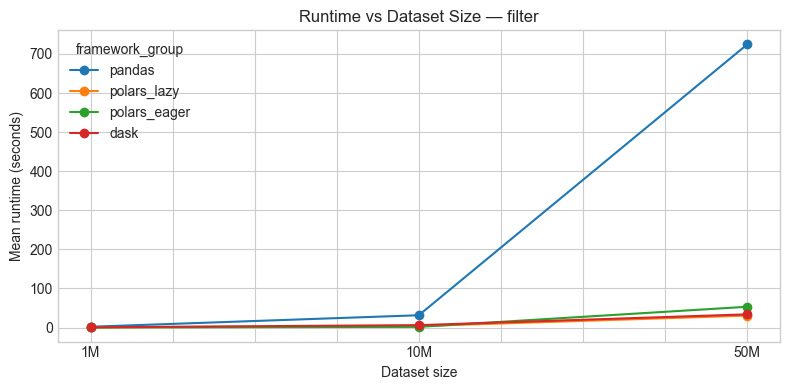

In [99]:
plot_runtime_vs_dataset_size_for_workload(
    size_summary=size_summary,
    workload="filter",
    row_order=ROW_ORDER
)

### Nhận xét

Biểu đồ `Runtime vs Dataset Size — filter` cho thấy filter workload có scaling behavior khác nhau rất rõ giữa các framework khi dataset size tăng từ `1M` lên `50M`.

`pandas` là framework nhạy nhất với dataset size trong filter workload. Runtime tăng rất mạnh ở `50M`, vượt xa các framework còn lại. Điều này cho thấy Pandas scale kém hơn trong filter end-to-end workload, đặc biệt khi dữ liệu lớn và kết quả sau filter cần được materialize trong memory.

Ba framework còn lại gồm `polars_lazy`, `polars_eager`, và `dask` có runtime thấp hơn nhiều so với Pandas ở mọi dataset size. Ở `1M` và `10M`, runtime của các framework này gần như nằm sát nhau ở mức thấp. Khi lên `50M`, runtime bắt đầu tách rõ hơn, nhưng vẫn thấp hơn Pandas rất nhiều.

Trong nhóm non-Pandas, `polars_lazy` và `dask` giữ runtime thấp hơn `polars_eager` ở `50M`. Điều này gợi ý rằng lazy execution hoặc partitioned execution có lợi hơn khi filter workload mở rộng lên dataset lớn.

Tóm lại, filter workload cho thấy Pandas là framework bị ảnh hưởng mạnh nhất bởi row growth, trong khi Polars và Dask scale tốt hơn đáng kể. Kết quả này cũng giải thích vì sao `pandas filter` có runtime growth rất cao trong bảng sensitivity.

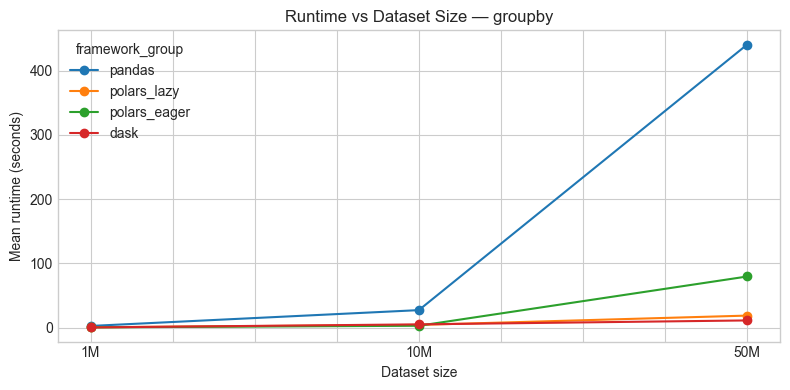

In [100]:
plot_runtime_vs_dataset_size_for_workload(
    size_summary=size_summary,
    workload="groupby",
    row_order=ROW_ORDER
)

### Nhận xét

Biểu đồ `Runtime vs Dataset Size — groupby` cho thấy `groupby` workload cũng có sự khác biệt scaling rất rõ giữa các framework khi dataset size tăng từ `1M` lên `50M`.

`pandas` tiếp tục là framework có runtime tăng mạnh nhất. Ở `1M` và `10M`, runtime vẫn còn tương đối thấp hơn so với mức ở `50M`, nhưng khi lên `50M`, runtime tăng vọt và vượt xa các framework còn lại. Điều này cho thấy Pandas scale kém hơn trong aggregation workload khi dữ liệu lớn.

Trong nhóm Polars, `polars_eager` tăng mạnh hơn `polars_lazy` khi dataset size tăng. Ở `50M`, `polars_eager` có runtime cao hơn đáng kể so với `polars_lazy`, cho thấy lazy execution có lợi hơn cho groupby workload ở scale lớn trong bộ kết quả này.

`dask` có runtime thấp và tăng khá chậm qua các dataset size. Đây là kết quả phù hợp với các bảng ranking trước đó, nơi Dask đứng đầu về runtime ở `groupby`. Điều này gợi ý rằng partitioned execution của Dask hoạt động hiệu quả với aggregation workload trong real row-scaling benchmark hiện tại.

Tóm lại, `groupby` cho thấy Dask scale tốt nhất trong nhóm framework được so sánh, tiếp theo là `polars_lazy`. Pandas bị ảnh hưởng mạnh nhất khi row count tăng, còn `polars_eager` có runtime tăng đáng kể ở `50M`.

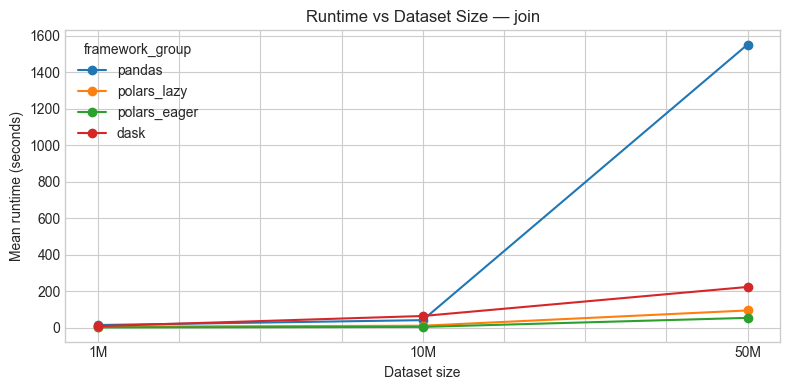

In [101]:
plot_runtime_vs_dataset_size_for_workload(
    size_summary=size_summary,
    workload="join",
    row_order=ROW_ORDER
)

### Nhận xét

Biểu đồ `Runtime vs Dataset Size — join` cho thấy `join` là workload có mức tăng runtime mạnh nhất khi dataset size tăng, đặc biệt đối với `pandas`.

`pandas` tăng rất mạnh ở `50M`, vượt xa toàn bộ các framework còn lại. Điều này cho thấy join workload trong Pandas scale kém ở dữ liệu lớn, nhiều khả năng do chi phí key matching, hash table construction, memory allocation, và final result materialization tăng mạnh khi input lớn hơn.

`dask` cũng có runtime tăng đáng kể khi dataset size tăng, đặc biệt từ `10M` lên `50M`. Dask vẫn nhanh hơn Pandas ở `50M`, nhưng chậm hơn nhóm Polars khá rõ. Điều này phù hợp với nhận xét trước đó rằng join có thể tạo overhead lớn cho Dask do partition handling, scheduling, hoặc shuffle-like behavior.

Trong nhóm Polars, `polars_eager` có runtime thấp nhất ở `50M`, tiếp theo là `polars_lazy`. Điều này củng cố kết luận từ ranking section rằng `polars_eager` là framework xử lý join hiệu quả nhất trong real row-scaling results hiện tại.

Ở `1M` và `10M`, khoảng cách giữa các framework chưa quá lớn, nhưng khi lên `50M`, sự khác biệt trở nên rất rõ. Điều này cho thấy join workload là một trong những workload nhạy nhất với dataset size và dễ bộc lộ khác biệt execution strategy giữa các framework.

Tóm lại, `join` là workload phân biệt framework mạnh nhất khi scale tăng. `pandas` bị ảnh hưởng nặng nhất, `dask` có overhead đáng kể ở scale lớn, trong khi `polars_eager` và `polars_lazy` giữ runtime thấp hơn nhiều.

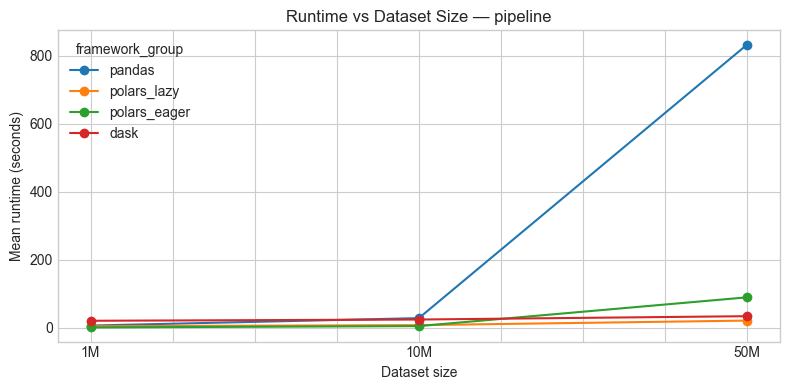

In [102]:
plot_runtime_vs_dataset_size_for_workload(
    size_summary=size_summary,
    workload="pipeline",
    row_order=ROW_ORDER
)

### Nhận xét

Biểu đồ `Runtime vs Dataset Size — pipeline` cho thấy `pipeline` workload có scaling behavior rất khác nhau giữa các framework khi dataset size tăng từ `1M` lên `50M`.

`pandas` có runtime tăng mạnh nhất. Ở `1M` và `10M`, runtime của Pandas vẫn chưa quá tách biệt, nhưng khi lên `50M`, runtime tăng vọt lên hơn `800s`, vượt xa toàn bộ các framework còn lại. Điều này cho thấy Pandas scale kém trong multi-step end-to-end workload, đặc biệt khi pipeline phải xử lý nhiều operation và materialize intermediate hoặc final results.

`polars_lazy` có runtime thấp nhất ở `50M`, cho thấy lazy execution có lợi rõ ràng trong pipeline workload. Đây là kết quả phù hợp với kỳ vọng vì pipeline gồm nhiều bước, nên optimizer có nhiều cơ hội áp dụng projection pushdown, predicate pushdown, reorder hoặc fuse operation, và hạn chế intermediate materialization.

`dask` giữ runtime tương đối ổn định hơn Pandas và thấp hơn nhiều ở `50M`. Tuy nhiên, Dask vẫn chậm hơn `polars_lazy` trong pipeline workload này, có thể do scheduling overhead hoặc chi phí xử lý graph execution.

`polars_eager` tăng nhiều hơn `polars_lazy` khi dataset size tăng. Điều này cho thấy eager execution có thể kém lợi thế hơn trong workload nhiều bước, vì mỗi bước có khả năng materialize intermediate result thay vì tối ưu toàn bộ query plan.

Tóm lại, `pipeline` là workload thể hiện rõ lợi thế của `polars_lazy` so với eager execution và Pandas. Với real row-scaling results hiện tại, `polars_lazy` là lựa chọn tốt nhất cho pipeline nếu ưu tiên runtime, trong khi Pandas là framework bị ảnh hưởng mạnh nhất khi row count tăng.

## 13. Supporting Evidence from Size, Stress, 100M, and Colab Results

Các section sau dùng supporting result groups để kiểm tra liệu pattern workload từ main benchmark có còn hợp lý dưới memory pressure, skew/high-cardinality, 100M scale, hoặc constrained runtime environment hay không.

Các bảng này **không** được dùng để rank toàn bộ framework trong main conclusion.


### 13.1 Physical Scaling / Memory Pressure

Câu hỏi: workload nào degrade hoặc fail trước khi physical dataset size tăng?


In [103]:
size_status = (
    df_size
    .groupby(["framework_group", "workload", "dataset_size", "status"], observed=True)
    .size()
    .rename("n_runs")
    .reset_index()
    .sort_values(["framework_group", "workload", "dataset_size", "status"])
)

size_ok_summary = (
    df_size_ok
    .groupby(["workload", "framework_group", "dataset_size"], observed=True)
    .agg(
        mean_runtime=("runtime_sec", "mean"),
        mean_memory=("peak_memory_mb", "mean"),
        n_runs=("runtime_sec", "count"),
    )
    .reset_index()
)

display(size_status)
display(size_ok_summary.head(30))


,framework_group,workload,dataset_size,status,n_runs
0,pandas,filter,10GB,ok,3
1,pandas,filter,20GB,ok,3
2,pandas,filter,5GB,ok,3
3,pandas,groupby,10GB,ok,3
4,pandas,groupby,20GB,ok,3
5,pandas,groupby,5GB,ok,3
6,pandas,join,10GB,ok,3
7,pandas,join,20GB,ok,3
8,pandas,join,5GB,ok,3
9,pandas,pipeline,10GB,ok,3


,workload,framework_group,dataset_size,mean_runtime,mean_memory,n_runs
0,filter,dask,10GB,4.707600,9484.330000,3
1,filter,dask,20GB,14.954000,11519.763333,3
2,filter,dask,5GB,2.258967,4801.816667,3
3,filter,pandas,10GB,28.712933,8794.096667,3
4,filter,pandas,20GB,196.362700,11882.790000,3
5,filter,pandas,5GB,13.697167,4858.973333,3
6,filter,polars_eager,10GB,2.753367,6539.640000,3
7,filter,polars_eager,20GB,8.020333,12039.570000,3
8,filter,polars_eager,5GB,1.153267,3287.260000,3
9,filter,polars_lazy,10GB,3.622767,5149.633333,3


### Nhận xét

Bảng `size_status` cho thấy nhóm `Physical Scaling / Memory Pressure` có dữ liệu đầy đủ cho cả bốn framework: `pandas`, `polars_lazy`, `polars_eager`, và `dask`. Mỗi framework đều có đủ bốn workload gồm `filter`, `groupby`, `join`, và `pipeline`, trên ba mức `dataset_size`: `5GB`, `10GB`, và `20GB`. Tất cả các tổ hợp được hiển thị đều có `status = ok` và `n_runs = 3`, nên không có dấu hiệu failed runs trong phần kết quả này.

Điều này nghĩa là trong phạm vi dữ liệu physical scaling hiện tại, chưa có workload nào fail trước khi physical dataset size tăng lên `20GB`. Vì vậy, câu hỏi “workload nào fail trước?” chưa thể trả lời bằng failure status; thay vào đó, notebook nên diễn giải theo hướng workload nào **degrade mạnh hơn** về runtime hoặc memory khi dataset size tăng.

Từ bảng `size_ok_summary`, `join` là workload cần chú ý nhất về degradation. Ví dụ, `pandas join` tăng từ khoảng `23.29s` ở `5GB` lên `450.76s` ở `20GB`, cho thấy runtime tăng rất mạnh khi physical size lớn hơn. `dask join` cũng tăng từ khoảng `14.67s` ở `5GB` lên `120.90s` ở `20GB`, đồng thời duy trì peak memory rất cao, trên `11000 MB` ở cả `5GB` và `20GB`.

`Filter` và `groupby` cũng degrade khi dataset size tăng, nhưng mức độ khác nhau theo framework. `pandas filter` tăng mạnh từ khoảng `13.70s` ở `5GB` lên `196.36s` ở `20GB`, còn `pandas groupby` tăng từ khoảng `15.02s` lên `135.99s`. Trong khi đó, `dask groupby` và `polars_lazy groupby` vẫn giữ runtime thấp hơn nhiều ở `20GB`, lần lượt khoảng `3.76s` và `4.89s`.

Về memory pressure, nhiều workload ở `20GB` đạt peak memory khoảng `11000–12000 MB`, đặc biệt với `pandas`, `polars_eager`, và `dask join`. Điều này cho thấy physical scaling chủ yếu làm tăng memory pressure, ngay cả khi các workload vẫn hoàn thành thành công.

Tóm lại, trong physical scaling results hiện tại, chưa có workload nào fail ở mức `5GB`, `10GB`, hoặc `20GB`. Tuy nhiên, `join` là workload degrade rõ nhất về runtime và memory, đặc biệt với `pandas` và `dask`. `GroupBy` nhìn chung ổn định hơn, nhất là với `dask` và `polars_lazy`. Vì đây là supporting evidence, kết quả này nên được dùng để bổ sung cho main workload analysis, không trộn vào main framework ranking.

### 13.2 Synthetic Stress: Skew and High-Cardinality

Câu hỏi: workload nào nhạy với skewed keys hoặc high-cardinality IDs?


In [104]:
stress_summary = (
    df_stress_ok
    .groupby(["workload", "framework_group", "dataset_size"], observed=True)
    .agg(
        mean_runtime=("runtime_sec", "mean"),
        mean_memory=("peak_memory_mb", "mean"),
        n_runs=("runtime_sec", "count"),
    )
    .reset_index()
    .sort_values(["workload", "framework_group", "dataset_size"])
)

stress_pivot = stress_summary.pivot_table(
    index=["workload", "framework_group"],
    columns="dataset_size",
    values=["mean_runtime", "mean_memory"],
    observed=True,
)

if {("mean_runtime", "10M_highuid"), ("mean_runtime", "10M_skewed")}.issubset(stress_pivot.columns):
    stress_sensitivity = pd.DataFrame(index=stress_pivot.index)
    stress_sensitivity["skew_vs_highuid_runtime"] = (
        stress_pivot[("mean_runtime", "10M_skewed")] / stress_pivot[("mean_runtime", "10M_highuid")]
    )
    stress_sensitivity["skew_vs_highuid_memory"] = (
        stress_pivot[("mean_memory", "10M_skewed")] / stress_pivot[("mean_memory", "10M_highuid")]
    )
    display(stress_sensitivity.reset_index().sort_values("skew_vs_highuid_runtime", ascending=False))
else:
    display(stress_summary)


,workload,framework_group,skew_vs_highuid_runtime,skew_vs_highuid_memory
0,filter,dask,0.932713,1.039322
2,filter,polars_eager,0.733614,1.003528
12,pipeline,dask,0.663823,0.869531
6,groupby,polars_eager,0.656705,0.998727
14,pipeline,polars_eager,0.645588,1.010671
10,join,polars_eager,0.620646,1.010423
9,join,pandas,0.595919,0.917250
1,filter,pandas,0.580019,0.884461
13,pipeline,pandas,0.571982,0.884104
15,pipeline,polars_lazy,0.514928,0.610062


### Nhận xét

Bảng `Synthetic Stress: Skew and High-Cardinality` so sánh runtime và memory giữa hai synthetic stress condition: `skewed keys` và `high-cardinality IDs`. Các cột `skew_vs_highuid_runtime` và `skew_vs_highuid_memory` được hiểu là tỷ lệ giữa skewed scenario và high-UID scenario.

Giá trị lớn hơn `1.0` nghĩa là `skewed keys` tốn runtime hoặc memory nhiều hơn `high-cardinality IDs`. Giá trị nhỏ hơn `1.0` nghĩa là `high-cardinality IDs` nặng hơn skewed keys trong cùng `workload + framework_group`.

Kết quả cho thấy hầu hết `skew_vs_highuid_runtime` đều nhỏ hơn `1.0`. Điều này nghĩa là trong synthetic stress results hiện tại, `high-cardinality IDs` thường tạo runtime pressure lớn hơn so với skewed keys. Nói cách khác, nhiều workload nhạy với số lượng unique IDs hơn là chỉ nhạy với key skew.

Mức chênh lệch rõ nhất nằm ở `groupby` và `join`. Ví dụ, `polars_lazy groupby` có runtime ratio chỉ khoảng `0.09`, cho thấy high-cardinality groupby chậm hơn skewed groupby rất nhiều. `dask groupby` cũng có ratio khoảng `0.24`, và `dask join` khoảng `0.32`, cho thấy high-cardinality IDs gây áp lực lớn cho các workload dựa vào hash table, key grouping, hoặc key matching.

Về memory, phần lớn ratio nằm gần `1.0`, nghĩa là memory usage giữa skewed và high-UID không khác biệt quá lớn trong nhiều trường hợp. Tuy nhiên, có một vài điểm đáng chú ý: `dask join` có memory ratio khoảng `1.26`, nghĩa là skewed join dùng nhiều memory hơn high-UID join trong Dask; ngược lại, `polars_lazy groupby` có memory ratio khoảng `0.39`, cho thấy high-cardinality groupby dùng memory cao hơn đáng kể so với skewed groupby trong Polars Lazy.

`Filter` nhìn chung ít nhạy hơn với skew hoặc high-cardinality so với `groupby` và `join`, vì filter không phụ thuộc nhiều vào key cardinality hoặc key distribution. Các ratio của filter thường gần hơn với `1.0`, đặc biệt ở Dask và Polars Eager.

`Pipeline` có sensitivity trung gian. Một số framework như `polars_lazy` có runtime ratio khoảng `0.51`, cho thấy high-cardinality IDs vẫn tạo áp lực lớn hơn, nhưng mức độ không cực đoan như `polars_lazy groupby`.

Tóm lại, trong synthetic stress results hiện tại, `high-cardinality IDs` là stress condition gây runtime pressure mạnh hơn `skewed keys` ở phần lớn workload-framework combinations. Các workload nhạy nhất là `groupby` và `join`, vì chúng phụ thuộc trực tiếp vào key cardinality, hash table size, và key matching. Đây là supporting evidence quan trọng cho kết luận rằng workload cost không chỉ phụ thuộc vào số dòng, mà còn phụ thuộc mạnh vào phân phối key và cardinality.

### 13.3 100M Scale Feasibility

Câu hỏi: workload nào còn feasible ở 100M rows?

Lưu ý: section này không rank toàn bộ framework vì 100M files hiện chỉ có Polars Lazy và Dask.


In [105]:
scale_100m_summary = (
    df_100m
    .groupby(["framework_group", "workload", "dataset_size", "status"], observed=True)
    .agg(
        n_runs=("runtime_sec", "count"),
        mean_runtime=("runtime_sec", "mean"),
        mean_memory=("peak_memory_mb", "mean"),
    )
    .reset_index()
    .sort_values(["workload", "framework_group", "status"])
)

scale_100m_summary


,framework_group,workload,dataset_size,status,n_runs,mean_runtime,mean_memory
0,polars_lazy,filter,100M,ok,3,81.088600,12117.460000
2,dask,filter,100M,ok,3,111.919833,11466.533333
1,polars_lazy,groupby,100M,ok,3,12.661767,3540.150000
3,dask,groupby,100M,ok,3,17.161267,6270.380000


### Nhận xét

Bảng `100M Scale Feasibility` cho thấy ở dataset `100M`, cả `polars_lazy` và `dask` đều hoàn thành thành công các workload được chạy, gồm `filter` và `groupby`. Tất cả các dòng đều có `status = ok` và `n_runs = 3`, nên trong phạm vi 100M results hiện tại, hai workload này được xem là feasible.

Tuy nhiên, section này không nên dùng để rank toàn bộ framework vì chỉ có `polars_lazy` và `dask`. Ngoài ra, 100M results hiện chỉ bao gồm `filter` và `groupby`, không bao gồm `join` và `pipeline`. Vì vậy, kết luận chỉ nên giới hạn ở large-scale feasibility cho hai workload này.

Về runtime, `polars_lazy` nhanh hơn `dask` ở cả hai workload. Với `filter`, `polars_lazy` có mean runtime khoảng `81.09s`, trong khi `dask` khoảng `111.92s`. Với `groupby`, `polars_lazy` khoảng `12.66s`, còn `dask` khoảng `17.16s`.

Về memory, pattern không hoàn toàn giống runtime. Ở `filter`, `dask` dùng peak memory thấp hơn một chút, khoảng `11466.53 MB`, so với `polars_lazy` khoảng `12117.46 MB`. Ngược lại, ở `groupby`, `polars_lazy` dùng memory thấp hơn rõ rệt, khoảng `3540.15 MB`, trong khi `dask` khoảng `6270.38 MB`.

Một điểm đáng chú ý là `groupby` ở 100M nhanh hơn nhiều so với `filter` cho cả hai framework. Điều này có thể xảy ra vì `groupby` tạo output nhỏ hơn sau aggregation, trong khi `filter` có thể phải materialize nhiều dòng kết quả hơn. Do đó, workload feasibility ở 100M không chỉ phụ thuộc vào input row count, mà còn phụ thuộc mạnh vào output size và materialization behavior.

Tóm lại, với 100M rows, `filter` và `groupby` đều feasible cho `polars_lazy` và `dask`. Trong hai framework được kiểm tra, `polars_lazy` có runtime tốt hơn ở cả hai workload, trong khi memory advantage phụ thuộc vào workload: `dask` thấp hơn một chút ở `filter`, còn `polars_lazy` thấp hơn rõ ở `groupby`.

### 13.4 Colab / Environment Sensitivity

Câu hỏi: workload nào nhạy với Colab hoặc constrained runtime environment?

Vì Colab data hiện có `1M` và `10M`, comparison dưới đây ghép với main real results ở cùng dataset size.


In [106]:
local_1m_10m = df_real_ok[df_real_ok["dataset_size"].astype(str).isin(["1M", "10M"])].copy()
local_1m_10m["environment"] = "local_windows"
colab_1m_10m = df_colab_ok.copy()
colab_1m_10m["environment"] = "colab_linux"

env_compare = pd.concat([local_1m_10m, colab_1m_10m], ignore_index=True)

env_summary = (
    env_compare
    .groupby(["environment", "framework_group", "workload", "dataset_size"], observed=True)
    .agg(
        mean_runtime=("runtime_sec", "mean"),
        mean_memory=("peak_memory_mb", "mean"),
        n_runs=("runtime_sec", "count"),
    )
    .reset_index()
)

env_pivot = env_summary.pivot_table(
    index=["framework_group", "workload", "dataset_size"],
    columns="environment",
    values=["mean_runtime", "mean_memory"],
    observed=True,
)

if {("mean_runtime", "colab_linux"), ("mean_runtime", "local_windows")}.issubset(env_pivot.columns):
    env_sensitivity = pd.DataFrame(index=env_pivot.index)
    env_sensitivity["colab_vs_local_runtime"] = (
        env_pivot[("mean_runtime", "colab_linux")] / env_pivot[("mean_runtime", "local_windows")]
    )
    env_sensitivity["colab_vs_local_memory"] = (
        env_pivot[("mean_memory", "colab_linux")] / env_pivot[("mean_memory", "local_windows")]
    )
    display(env_sensitivity.reset_index().sort_values("colab_vs_local_runtime", ascending=False))
else:
    display(env_summary)


,framework_group,workload,dataset_size,colab_vs_local_runtime,colab_vs_local_memory
18,polars_eager,groupby,10M,2.549671,0.926134
16,polars_eager,filter,10M,2.506405,0.944397
17,polars_eager,filter,1M,2.210554,0.805893
19,polars_eager,groupby,1M,1.625805,0.838510
9,pandas,filter,1M,1.481127,0.885594
11,pandas,groupby,1M,1.446303,0.924100
22,polars_eager,pipeline,10M,1.445614,0.952127
20,polars_eager,join,10M,1.444923,0.684591
3,dask,groupby,1M,1.441136,1.092440
26,polars_lazy,groupby,10M,1.410560,0.509663


### Nhận xét

Bảng `Colab / Environment Sensitivity` so sánh runtime và memory giữa Colab và local main real results ở cùng `framework_group`, `workload`, và `dataset_size`. Hai cột `colab_vs_local_runtime` và `colab_vs_local_memory` được hiểu là tỷ lệ giữa Colab và local.

Giá trị lớn hơn `1.0` nghĩa là Colab chậm hơn hoặc dùng nhiều memory hơn local. Giá trị nhỏ hơn `1.0` nghĩa là Colab nhanh hơn hoặc dùng ít memory hơn local trong cùng điều kiện so sánh.

Kết quả cho thấy environment sensitivity không đồng đều giữa các workload và framework. Một số workload chạy chậm hơn trên Colab, đặc biệt là `polars_eager groupby 10M` với runtime ratio khoảng `2.55x`, `polars_eager filter 10M` khoảng `2.51x`, và `polars_eager filter 1M` khoảng `2.21x`. Điều này cho thấy Polars Eager trong một số workload scan hoặc aggregation có thể nhạy với môi trường Colab hơn local.

Ngược lại, một số workload có runtime ratio nhỏ hơn `1.0`, nghĩa là Colab nhanh hơn local trong các kết quả này. Các trường hợp nổi bật gồm `polars_lazy join 1M`, `dask pipeline 1M`, `dask join 10M`, và `pandas join 1M`. Điều này cho thấy environment comparison không thể được hiểu đơn giản là Colab luôn chậm hơn local; kết quả còn phụ thuộc vào workload, framework, dataset size, phần cứng, memory limit, filesystem, và execution strategy.

Về memory, đa số `colab_vs_local_memory` nhỏ hơn `1.0`, nghĩa là peak memory được ghi nhận trên Colab thường thấp hơn local. Tuy nhiên, điều này không nhất thiết có nghĩa là Colab memory-efficient hơn. Peak memory có thể khác do runtime limit, measurement method, memory allocator, process behavior, hoặc cách môi trường Colab quản lý tài nguyên.

`Filter` và `groupby` có nhiều trường hợp Colab chậm hơn local, đặc biệt với `polars_eager` và một số trường hợp `pandas` hoặc `dask`. Trong khi đó, `join` và `pipeline` có nhiều ratio nhỏ hơn `1.0`, cho thấy kết quả environment-sensitive và không đồng nhất.

Tóm lại, Colab results cho thấy workload performance có thể thay đổi đáng kể theo execution environment. Tuy nhiên, vì comparison hiện chỉ có `1M` và `10M`, section này nên được dùng như `supporting evidence` cho environment sensitivity, không dùng để thay thế hoặc trộn vào main real-data ranking.

## 14. Workload-Specific Bottleneck Interpretation

Phần này diễn giải kết quả theo bottleneck của từng workload. Các bảng phía trên cho biết workload nào nhanh/chậm; phần này giải thích vì sao pattern đó có thể xuất hiện trong end-to-end dataframe benchmark.


In [107]:
fastest_by_workload = (
    runtime_rank[runtime_rank["runtime_rank"] == 1]
    .sort_values("workload")
    [["workload", "framework_group", "mean_runtime"]]
)

lowest_memory_by_workload = (
    memory_rank[memory_rank["memory_rank"] == 1]
    .sort_values("workload")
    [["workload", "framework_group", "mean_memory"]]
)

interpretation_base = (
    runtime_by_workload[["mean_runtime"]]
    .join(memory_by_workload[["mean_memory"]], how="outer")
    .reset_index()
    .sort_values("workload")
)

print("Fastest framework by workload:")
display(fastest_by_workload)
print("Lowest-memory framework by workload:")
display(lowest_memory_by_workload)
print("Workload-level runtime/memory profile:")
display(interpretation_base)


Fastest framework by workload:


,workload,framework_group,mean_runtime
1,filter,polars_lazy,11.532633
7,groupby,dask,5.550411
10,join,polars_eager,19.370056
13,pipeline,polars_lazy,11.172022


Lowest-memory framework by workload:


,workload,framework_group,mean_memory
2,filter,polars_eager,4373.487778
7,groupby,dask,3117.016667
10,join,polars_eager,4954.616667
15,pipeline,dask,4561.186667


Workload-level runtime/memory profile:


,workload,mean_runtime,mean_memory
0,filter,74.043383,5595.711389
1,groupby,49.506350,5185.558611
2,join,172.515711,6856.876389
3,pipeline,89.618292,6073.658333


### Nhận xét

Các bảng trong section này tổng hợp ba góc nhìn chính: framework nhanh nhất theo từng workload, framework dùng peak memory thấp nhất theo từng workload, và workload-level runtime/memory profile. Kết quả cho thấy mỗi workload có bottleneck khác nhau, nên framework recommendation cũng thay đổi theo workload.

Ở `filter`, `polars_lazy` là framework nhanh nhất với mean runtime khoảng `11.53s`, trong khi `polars_eager` dùng peak memory thấp nhất, khoảng `4373.49 MB`. Điều này cho thấy filter workload có thể hưởng lợi từ lazy scan optimization về runtime, nhưng eager execution lại có memory footprint thấp hơn trong bộ kết quả này. Bottleneck chính của filter không chỉ là điều kiện lọc, mà còn gồm parquet scan, predicate pushdown, và materialization của output DataFrame.

Ở `groupby`, `dask` đứng đầu cả về runtime và memory, với mean runtime khoảng `5.55s` và mean memory khoảng `3117.02 MB`. Đây là workload mà Dask thể hiện tốt nhất. Bottleneck của groupby thường nằm ở aggregation state, key cardinality, và hash table size. Kết quả này gợi ý rằng partitioned execution của Dask xử lý aggregation workload hiệu quả trong main real-data results hiện tại.

Ở `join`, `polars_eager` đứng đầu cả về runtime và memory, với mean runtime khoảng `19.37s` và mean memory khoảng `4954.62 MB`. Trong workload-level profile, `join` cũng là workload nặng nhất tổng thể, với mean runtime khoảng `172.52s` và mean memory khoảng `6856.88 MB`. Điều này xác nhận rằng join là bottleneck lớn nhất trong benchmark, do chi phí key matching, hash table construction, memory allocation, và final result materialization.

Ở `pipeline`, `polars_lazy` là framework nhanh nhất với mean runtime khoảng `11.17s`, trong khi `dask` dùng memory thấp nhất, khoảng `4561.19 MB`. Đây là ví dụ rõ ràng cho trade-off giữa runtime và memory. Pipeline workload gồm nhiều bước, nên bottleneck có thể đến từ intermediate materialization, query planning, và khả năng optimizer kết hợp nhiều operation. `polars_lazy` có lợi thế runtime vì có thể tối ưu query plan end-to-end, còn Dask có lợi thế memory trong bộ kết quả này.

Workload-level profile cho thấy thứ tự runtime tổng thể là `join > pipeline > filter > groupby`, còn thứ tự memory tổng thể là `join > pipeline > filter > groupby`. Điều này cho thấy `join` và `pipeline` là hai workload cần chú ý nhất khi phân tích bottleneck, vì chúng vừa tốn runtime vừa tạo memory pressure cao hơn.

Tóm lại, bottleneck không giống nhau giữa các workload. `Filter` chủ yếu bị ảnh hưởng bởi scan và output materialization, `GroupBy` bị ảnh hưởng bởi aggregation state và key cardinality, `Join` bị ảnh hưởng mạnh bởi key matching và memory pressure, còn `Pipeline` phụ thuộc nhiều vào intermediate results và optimizer behavior. Vì vậy, recommendation cuối cùng nên theo workload-specific trade-off thay vì một ranking framework duy nhất.

### 14.1 Filter: Scan and Materialization Bottleneck

`Filter` chủ yếu phản ánh chi phí `scan/decode parquet`, `predicate evaluation`, và `output materialization`. Về lý thuyết, filter là workload đơn giản hơn `join` hoặc `pipeline`, nhưng trong end-to-end benchmark, nó không chỉ đo chi phí kiểm tra điều kiện boolean.

Nếu framework hỗ trợ tốt `predicate pushdown` hoặc `projection pushdown`, filter có thể chạy nhanh vì giảm được lượng dữ liệu cần đọc hoặc xử lý. Đây là lý do `polars_lazy` có lợi thế runtime trong filter workload. Tuy nhiên, nếu điều kiện lọc giữ lại nhiều dòng, framework vẫn phải materialize một output DataFrame lớn, làm tăng runtime và peak memory.

Vì vậy, `filter` nên được hiểu là workload scan-heavy và materialization-sensitive. Nó là baseline tốt để so sánh các workload khác, nhưng không nên xem là workload “rẻ” tuyệt đối trong mọi trường hợp.

### 14.2 GroupBy: Aggregation and Cardinality Bottleneck

`GroupBy` phụ thuộc nhiều vào `key cardinality`, `key distribution`, kích thước `hash table`, và `aggregation state`. Nếu số lượng group nhỏ hơn nhiều so với số dòng đầu vào, output sau aggregation có thể rất nhỏ. Khi đó, `groupby` có thể có runtime và memory thấp hơn `filter`, vì filter có thể phải materialize nhiều dòng kết quả hơn.

Trong main real-data results, `groupby` là workload có workload-level mean runtime và mean memory thấp nhất. Điều này cho thấy aggregation workload hiện tại không tạo output quá lớn, hoặc framework xử lý aggregation khá hiệu quả. `Dask` đặc biệt nổi bật ở groupby, cả về runtime lẫn peak memory, cho thấy partitioned aggregation có lợi trong workload này.

Tuy nhiên, kết quả này không có nghĩa `groupby` luôn nhẹ. Trong synthetic stress results, high-cardinality IDs có thể làm groupby trở nên nặng hơn nhiều vì số lượng group và kích thước hash table tăng. Do đó, bottleneck chính của `groupby` nằm ở cardinality và distribution của key, không chỉ ở row count.

### 14.3 Join: Hash Table, Shuffle, and Memory Bottleneck

`Join` là workload nhạy nhất với `key matching`, `hash table construction`, `build/probe cost`, `partitioning`, `shuffle behavior`, và kích thước output sau join. Trong end-to-end benchmark, join không chỉ đo thuật toán join thuần túy, mà còn bao gồm chi phí đọc dữ liệu, chuẩn bị key, cấp phát memory, tạo intermediate structures, và materialize final result.

Các kết quả trước đó cho thấy `join` là workload có mean runtime và mean peak memory cao nhất. Điều này phù hợp với bản chất của join: nếu join key có cardinality cao, nếu output lớn, hoặc nếu framework cần shuffle/partition lại dữ liệu, runtime và memory có thể tăng mạnh.

Trong main real-data results, `polars_eager` là framework tốt nhất cho join cả về runtime và memory. Ngược lại, `dask` có amplification cao hơn so với filter baseline, cho thấy join có thể tạo overhead lớn trong partitioned execution. Vì vậy, `join` là workload quan trọng nhất để phát hiện memory bottleneck và khác biệt execution strategy giữa các framework.

### 14.4 Pipeline: Compounded Operation and Intermediate Materialization Bottleneck

`Pipeline` kết hợp nhiều operator trong cùng một workflow, nên bottleneck của nó phụ thuộc vào thứ tự operation, kích thước intermediate results, và khả năng optimizer của framework. Pipeline không đơn giản là tổng của filter, groupby, join hoặc các bước riêng lẻ; nó là một end-to-end workload có thể được tối ưu hoặc bị amplify tùy execution model.

Nếu engine có thể tối ưu toàn bộ query plan, ví dụ `predicate pushdown`, `projection pushdown`, operation fusion, hoặc tránh materialize intermediate DataFrame, runtime có thể thấp hơn tổng chi phí từng bước. Đây là lý do `polars_lazy` thường có lợi thế rõ ràng trong pipeline workload.

Ngược lại, nếu framework phải materialize intermediate results nhiều lần, hoặc nếu pipeline tạo output/intermediate lớn, workload này có thể amplify cả runtime lẫn memory. Trong main results, `pipeline` là workload nặng thứ hai sau `join` theo cả runtime và memory, cho thấy multi-step analytics workflow có thể tạo bottleneck đáng kể.

Tóm lại, `pipeline` là workload đại diện tốt cho real-world dataframe analytics, vì người dùng thường không chạy một operator đơn lẻ mà chạy nhiều bước liên tiếp. Do đó, pipeline giúp đánh giá khả năng tối ưu end-to-end của framework, không chỉ tốc độ của từng operator riêng biệt.

## 15. Practical Recommendations by Workload

Bảng recommendation dưới đây được sinh từ kết quả thực tế: ưu tiên framework nhanh nhất, nhưng có note thêm nếu framework nhanh nhất khác framework dùng memory thấp nhất.


In [108]:
def build_recommendations(runtime_rank, memory_rank):
    fastest = (
        runtime_rank[runtime_rank["runtime_rank"] == 1]
        .rename(columns={"framework_group": "fastest_framework", "mean_runtime": "fastest_runtime_sec"})
        [["workload", "fastest_framework", "fastest_runtime_sec"]]
    )
    lowest = (
        memory_rank[memory_rank["memory_rank"] == 1]
        .rename(columns={"framework_group": "lowest_memory_framework", "mean_memory": "lowest_memory_mb"})
        [["workload", "lowest_memory_framework", "lowest_memory_mb"]]
    )
    rec = fastest.merge(lowest, on="workload", how="outer")
    rec["recommended_framework"] = rec["fastest_framework"]
    rec["reason"] = np.where(
        rec["fastest_framework"].astype(str) == rec["lowest_memory_framework"].astype(str),
        "Fastest and lowest-memory choice in the main real-data benchmark.",
        "Fastest in main real-data benchmark; check memory trade-off against the lowest-memory framework.",
    )
    return rec[[
        "workload",
        "recommended_framework",
        "fastest_runtime_sec",
        "lowest_memory_framework",
        "lowest_memory_mb",
        "reason",
    ]]

recommendations = build_recommendations(runtime_rank, memory_rank)
recommendations


,workload,recommended_framework,fastest_runtime_sec,lowest_memory_framework,lowest_memory_mb,reason
0,filter,polars_lazy,11.532633,polars_eager,4373.487778,Fastest in main real-data benchmark; check mem...
1,groupby,dask,5.550411,dask,3117.016667,Fastest and lowest-memory choice in the main r...
2,join,polars_eager,19.370056,polars_eager,4954.616667,Fastest and lowest-memory choice in the main r...
3,pipeline,polars_lazy,11.172022,dask,4561.186667,Fastest in main real-data benchmark; check mem...


### Nhận xét

Bảng `Practical Recommendations by Workload` tổng hợp recommendation theo từng workload dựa trên kết quả thực tế từ main real-data benchmark. Tiêu chí chính là chọn framework có runtime nhanh nhất, đồng thời ghi chú thêm nếu framework nhanh nhất khác với framework dùng peak memory thấp nhất.

Với `filter`, recommendation là `polars_lazy` vì đây là framework có mean runtime thấp nhất, khoảng `11.53s`. Tuy nhiên, framework dùng memory thấp nhất lại là `polars_eager`, khoảng `4373.49 MB`. Vì vậy, nếu ưu tiên tốc độ, `polars_lazy` là lựa chọn tốt hơn; nếu môi trường bị giới hạn memory, `polars_eager` có thể phù hợp hơn.

Với `groupby`, recommendation là `dask`. Đây là trường hợp rõ ràng nhất vì Dask vừa nhanh nhất, với mean runtime khoảng `5.55s`, vừa dùng memory thấp nhất, khoảng `3117.02 MB`. Điều này khiến Dask là lựa chọn thực tế tốt nhất cho groupby workload trong main real-data results hiện tại.

Với `join`, recommendation là `polars_eager`. Framework này vừa có runtime thấp nhất, khoảng `19.37s`, vừa có peak memory thấp nhất, khoảng `4954.62 MB`. Vì join là workload có runtime và memory pressure cao nhất trong workload-level profile, việc `polars_eager` đứng đầu ở cả hai tiêu chí là một kết quả quan trọng.

Với `pipeline`, recommendation là `polars_lazy` vì có mean runtime thấp nhất, khoảng `11.17s`. Tuy nhiên, framework dùng memory thấp nhất lại là `dask`, khoảng `4561.19 MB`. Vì vậy, pipeline workload có trade-off rõ ràng: chọn `polars_lazy` nếu ưu tiên tốc độ, chọn `dask` nếu ưu tiên peak memory thấp.

Tóm lại, recommendation không nên là một framework duy nhất cho mọi tình huống. Kết quả thực tế cho thấy `polars_lazy` phù hợp nhất cho `filter` và `pipeline` khi ưu tiên runtime, `dask` phù hợp nhất cho `groupby`, và `polars_eager` phù hợp nhất cho `join`. Nếu ưu tiên memory thay vì runtime, lựa chọn có thể thay đổi ở `filter` và `pipeline`.

## 16. Final Conclusion

Cell dưới đây trả lời lại research questions bằng kết quả tính từ dữ liệu hiện tại. Nếu CSV thay đổi, conclusion sẽ update theo số liệu mới khi chạy lại notebook.


In [109]:
most_memory_expensive = memory_by_workload.index[0]
fastest_map = fastest_by_workload.set_index("workload")["framework_group"].astype(str).to_dict()
lowest_memory_map = lowest_memory_by_workload.set_index("workload")["framework_group"].astype(str).to_dict()

ranking_changes = runtime_rank.groupby("workload", observed=True).first()["framework_group"].astype(str).nunique() > 1

pipeline_amp = runtime_amplification[runtime_amplification["workload"].astype(str) == "pipeline"]["mean_amplification"].mean()
join_amp = runtime_amplification[runtime_amplification["workload"].astype(str) == "join"]["mean_amplification"].mean()
groupby_amp = runtime_amplification[runtime_amplification["workload"].astype(str) == "groupby"]["mean_amplification"].mean()

most_runtime_sensitive = growth_table.iloc[0]
most_memory_sensitive = growth_table.sort_values("memory_growth_50M_vs_1M", ascending=False).iloc[0]

print("Final answers")
print("-------------")
print(f"1. Most runtime-expensive workload: {most_runtime_expensive}.")
print(f"2. Most memory-expensive workload: {most_memory_expensive}.")
print("3. Fastest framework by workload:", fastest_map)
print("4. Lowest-memory framework by workload:", lowest_memory_map)
print(f"5. Mean Join amplification vs Filter: {join_amp:.2f}x; GroupBy: {groupby_amp:.2f}x.")
print(f"6. Mean Pipeline amplification vs Filter: {pipeline_amp:.2f}x.")
print(f"7. Framework ranking changes by workload: {'yes' if ranking_changes else 'no'}.")
print(
    "8. Most runtime-sensitive to row count:",
    f"{most_runtime_sensitive['workload']} / {most_runtime_sensitive['framework_group']} ",
    f"with {most_runtime_sensitive['runtime_growth_50M_vs_1M']:.2f}x growth from 1M to 50M.",
)
print(
    "9. Most memory-sensitive to row count:",
    f"{most_memory_sensitive['workload']} / {most_memory_sensitive['framework_group']} ",
    f"with {most_memory_sensitive['memory_growth_50M_vs_1M']:.2f}x growth from 1M to 50M.",
)
print("10. Supporting groups should be read as confirmation/context, not as main ranking inputs.")


Final answers
-------------
1. Most runtime-expensive workload: join.
2. Most memory-expensive workload: join.
3. Fastest framework by workload: {'filter': 'polars_lazy', 'groupby': 'dask', 'join': 'polars_eager', 'pipeline': 'polars_lazy'}
4. Lowest-memory framework by workload: {'filter': 'polars_eager', 'groupby': 'dask', 'join': 'polars_eager', 'pipeline': 'dask'}
5. Mean Join amplification vs Filter: 5.41x; GroupBy: 1.03x.
6. Mean Pipeline amplification vs Filter: 5.24x.
7. Framework ranking changes by workload: yes.
8. Most runtime-sensitive to row count: filter / pandas  with 352.94x growth from 1M to 50M.
9. Most memory-sensitive to row count: filter / polars_lazy  with 18.08x growth from 1M to 50M.
10. Supporting groups should be read as confirmation/context, not as main ranking inputs.


### Nhận xét

Phần `Final answers` tổng hợp rõ các kết luận chính của notebook từ main real-data successful runs. Kết quả cho thấy `join` là workload đắt nhất ở cả hai chiều: runtime và peak memory. Đây là kết luận nhất quán với các bảng runtime, memory, amplification, và bottleneck interpretation trước đó.

Framework nhanh nhất thay đổi theo workload. `polars_lazy` nhanh nhất ở `filter` và `pipeline`, `dask` nhanh nhất ở `groupby`, còn `polars_eager` nhanh nhất ở `join`. Điều này xác nhận rằng không có một framework duy nhất thắng trên mọi workload.

Khi xét peak memory, recommendation cũng thay đổi: `polars_eager` dùng memory thấp nhất ở `filter` và `join`, còn `dask` dùng memory thấp nhất ở `groupby` và `pipeline`. Vì vậy, lựa chọn framework nên phụ thuộc vào mục tiêu cụ thể: ưu tiên runtime hay ưu tiên memory.

Các chỉ số amplification cho thấy `join` và `pipeline` làm tăng runtime mạnh nhất so với `filter baseline`, lần lượt khoảng `5.41x` và `5.24x`. Trong khi đó, `groupby` chỉ khoảng `1.03x`, nghĩa là groupby gần với filter hơn nhiều về runtime amplification trong main real-data benchmark.

Về sensitivity theo row count, tổ hợp nhạy nhất về runtime là `filter / pandas`, với runtime tăng khoảng `352.94x` khi dữ liệu tăng từ `1M` lên `50M`. Tổ hợp nhạy nhất về memory là `filter / polars_lazy`, với peak memory tăng khoảng `18.08x`. Các kết quả này cho thấy scaling behavior phụ thuộc mạnh vào cả workload và framework.

Tóm lại, notebook đưa ra một kết luận rõ ràng: `join` là workload nặng nhất tổng thể; `pipeline` cũng là workload cần chú ý vì runtime amplification cao; framework ranking thay đổi theo workload; và các nhóm supporting results chỉ nên được dùng làm context, không dùng làm input cho main ranking.